# Cognitive Stress Model

Visualizing physiological signals and self-reported stress levels from 22 subjects.

**Subjects:**
- **V1 (males with Stroop):** S04, S05, S08, S09, S10, S13, S14, S15, S17, S18
- **V2 (females without Stroop):** f01, f02, f03, f04, f05, f06, f08, f09, f10, f11, f12, f13

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Paths
dataset_path = '22subjects/STRESS'
stress_level_v1_path = 'WISE_data_files/Stress_Level_v1.csv'
stress_level_v2_path = 'WISE_data_files/Stress_Level_v2.csv'

# Subject lists
v1_subjects = ['S04', 'S05', 'S08', 'S09', 'S10', 'S13', 'S14', 'S15', 'S17', 'S18']
v2_subjects = ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f08', 'f09', 'f10', 'f11', 'f12', 'f13']
all_subjects = v1_subjects + v2_subjects

print(f"V1 Subjects (n={len(v1_subjects)}): {v1_subjects}")
print(f"V2 Subjects (n={len(v2_subjects)}): {v2_subjects}")
print(f"Total: {len(all_subjects)} subjects")

V1 Subjects (n=10): ['S04', 'S05', 'S08', 'S09', 'S10', 'S13', 'S14', 'S15', 'S17', 'S18']
V2 Subjects (n=12): ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f08', 'f09', 'f10', 'f11', 'f12', 'f13']
Total: 22 subjects


---
## Self-Reported Stress Levels

In [3]:
# Load V1 stress levels
stress_level_v1 = pd.read_csv(stress_level_v1_path, index_col=0)

print("V1 Stress Levels (Males with Stroop Test)")
print(f"Phases: {list(stress_level_v1.columns)}")
print(f"Subjects: {list(stress_level_v1.index)}")
stress_level_v1

V1 Stress Levels (Males with Stroop Test)
Phases: ['Baseline', 'Stroop', 'First Rest', 'TMCT', 'Second Rest', 'Real Opinion', 'Opposite Opinion', 'Subtract']
Subjects: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18']


,Baseline,Stroop,First Rest,TMCT,Second Rest,Real Opinion,Opposite Opinion,Subtract
S01,3.0,4.5,4.0,4.0,5.5,6.0,7.0,7.0
S02,2.0,4.0,2.0,2.0,2.0,4.0,5.0,4.0
S03,3.0,3.0,3.0,4.0,3.0,3.0,3.0,3.0
S04,3.0,3.0,2.0,3.0,1.0,1.0,1.0,1.0
S05,1.0,2.0,1.0,4.0,1.0,2.0,2.0,3.0
S06,2.0,3.0,2.0,5.0,3.0,3.0,3.0,5.0
S07,5.0,6.0,6.0,8.0,7.0,8.0,9.0,9.0
S08,0.0,1.0,1.0,5.5,1.5,0.5,0.5,1.5
S09,7.0,5.0,3.0,5.0,4.0,7.0,6.0,5.0
S10,4.0,4.0,4.0,6.0,5.0,5.0,5.0,5.0


In [4]:
# Load V2 stress levels
stress_level_v2 = pd.read_csv(stress_level_v2_path, index_col=0)

print("V2 Stress Levels (Females without Stroop Test)")
print(f"Phases: {list(stress_level_v2.columns)}")
print(f"Subjects: {list(stress_level_v2.index)}")
stress_level_v2

V2 Stress Levels (Females without Stroop Test)
Phases: ['Baseline', 'TMCT', 'First Rest', 'Real Opinion', 'Opposite Opinion', 'Second Rest', 'Subtract']
Subjects: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08', 'f09', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18']


,Baseline,TMCT,First Rest,Real Opinion,Opposite Opinion,Second Rest,Subtract
f01,2.0,5.0,2.0,3.0,4.0,2.0,3.0
f02,3.0,5.0,1.0,2.0,3.0,2.0,3.0
f03,5.0,8.0,1.0,3.0,5.0,1.0,6.0
f04,2.0,4.0,3.0,3.0,4.0,1.0,4.0
f05,3.0,4.0,3.0,3.0,3.0,2.0,3.0
f06,3.0,4.0,1.0,2.0,3.0,1.0,3.0
f07,1.0,4.0,1.0,3.0,1.0,1.0,3.0
f08,0.0,3.0,1.0,1.0,1.0,1.0,2.0
f09,5.0,6.0,3.0,4.0,4.0,3.0,5.0
f10,6.0,8.0,5.0,5.0,5.0,4.0,5.0


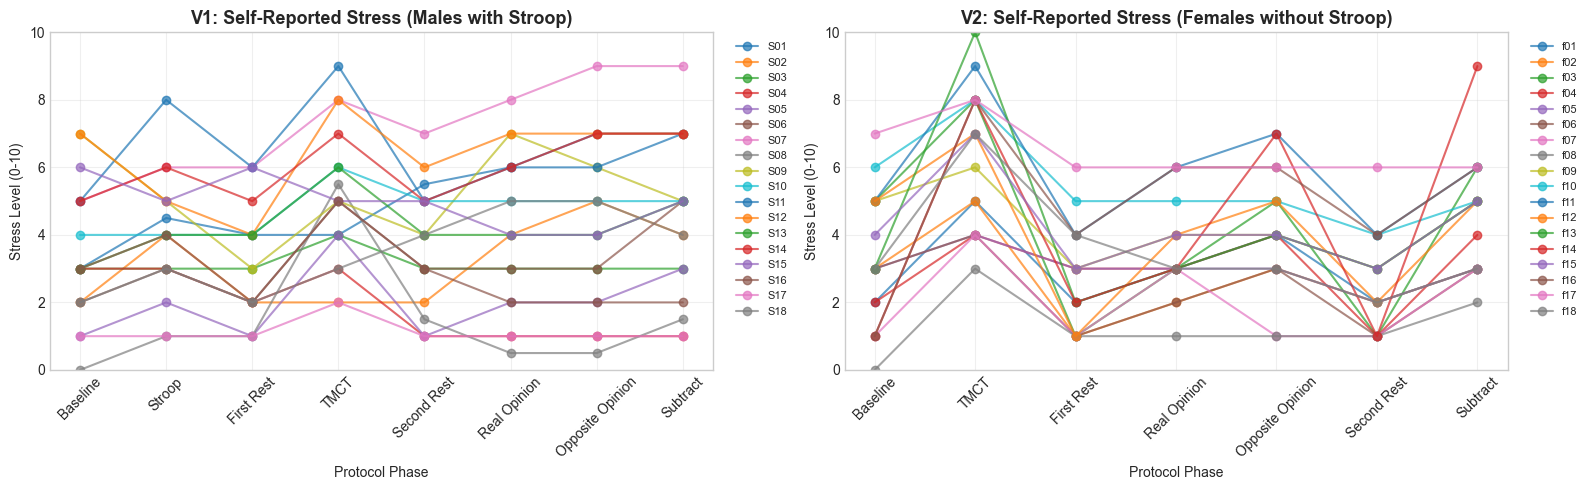

In [5]:
# Plot stress levels across phases
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# V1
for subject, row in stress_level_v1.iterrows():
    axes[0].plot(row.index, row.values, marker='o', alpha=0.7, label=subject)
axes[0].set_title('V1: Self-Reported Stress (Males with Stroop)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Protocol Phase')
axes[0].set_ylabel('Stress Level (0-10)')
axes[0].legend(bbox_to_anchor=(1.02, 1), fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 10)
axes[0].tick_params(axis='x', rotation=45)

# V2
for subject, row in stress_level_v2.iterrows():
    axes[1].plot(row.index, row.values, marker='o', alpha=0.7, label=subject)
axes[1].set_title('V2: Self-Reported Stress (Females without Stroop)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Protocol Phase')
axes[1].set_ylabel('Stress Level (0-10)')
axes[1].legend(bbox_to_anchor=(1.02, 1), fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 10)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

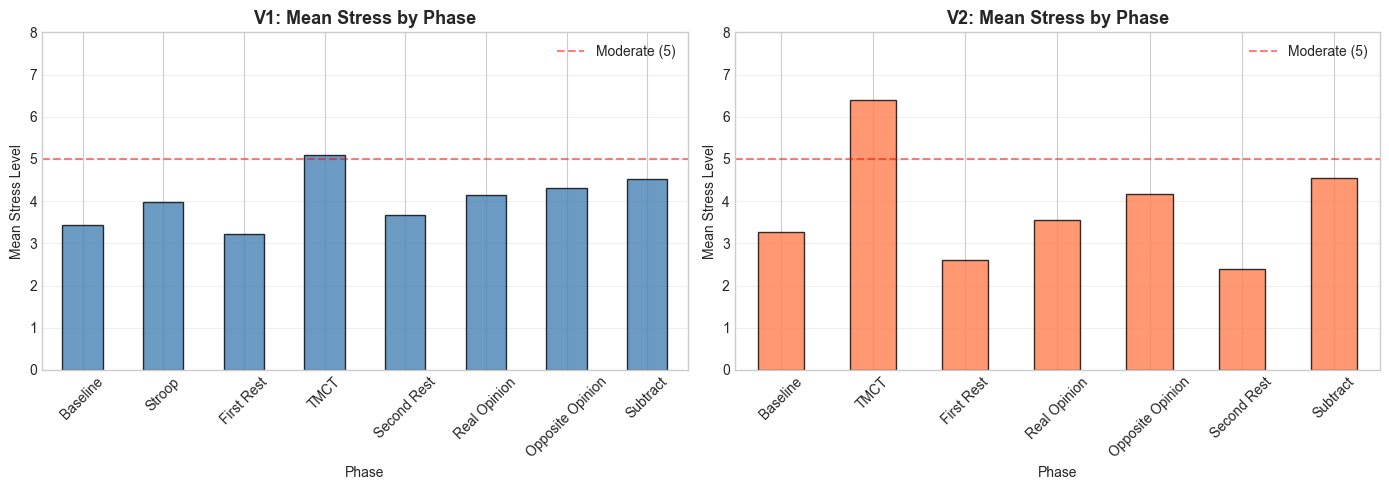

V1 - Phases ranked by stress:
  TMCT: 5.08
  Subtract: 4.53
  Opposite Opinion: 4.31
  Real Opinion: 4.14
  Stroop: 3.97
  Second Rest: 3.67
  Baseline: 3.44
  First Rest: 3.22

V2 - Phases ranked by stress:
  TMCT: 6.39
  Subtract: 4.56
  Opposite Opinion: 4.17
  Real Opinion: 3.56
  Baseline: 3.28
  First Rest: 2.61
  Second Rest: 2.39


In [6]:
# Mean stress by phase
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# V1
mean_v1 = stress_level_v1.mean()
mean_v1.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('V1: Mean Stress by Phase', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Mean Stress Level')
axes[0].set_xlabel('Phase')
axes[0].axhline(y=5, color='red', linestyle='--', alpha=0.5, label='Moderate (5)')
axes[0].set_ylim(0, 8)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

# V2
mean_v2 = stress_level_v2.mean()
mean_v2.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title('V2: Mean Stress by Phase', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean Stress Level')
axes[1].set_xlabel('Phase')
axes[1].axhline(y=5, color='red', linestyle='--', alpha=0.5, label='Moderate (5)')
axes[1].set_ylim(0, 8)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print rankings
print("V1 - Phases ranked by stress:")
for phase, val in mean_v1.sort_values(ascending=False).items():
    print(f"  {phase}: {val:.2f}")

print("\nV2 - Phases ranked by stress:")
for phase, val in mean_v2.sort_values(ascending=False).items():
    print(f"  {phase}: {val:.2f}")

---
## TMCT Stress Change Analysis

Analyzing which subjects experienced the largest changes in self-reported stress levels during the TMCT phase.

In [7]:
# Calculate stress change from Baseline to TMCT for all subjects
stress_changes = []

# V1 subjects (Males)
for subject in v1_subjects:
    if subject in stress_level_v1.index:
        baseline = stress_level_v1.loc[subject, 'Baseline']
        tmct = stress_level_v1.loc[subject, 'TMCT']
        change = tmct - baseline
        stress_changes.append({
            'Subject': subject,
            'Protocol': 'V1 (Male)',
            'Baseline': baseline,
            'TMCT': tmct,
            'Change': change
        })

# V2 subjects (Females)
for subject in v2_subjects:
    if subject in stress_level_v2.index:
        baseline = stress_level_v2.loc[subject, 'Baseline']
        tmct = stress_level_v2.loc[subject, 'TMCT']
        change = tmct - baseline
        stress_changes.append({
            'Subject': subject,
            'Protocol': 'V2 (Female)',
            'Baseline': baseline,
            'TMCT': tmct,
            'Change': change
        })

# Create dataframe and sort by change (largest increase first)
df_changes = pd.DataFrame(stress_changes)
df_changes_sorted = df_changes.sort_values('Change', ascending=False)

# Display results
print("=" * 70)
print("SELF-REPORTED STRESS CHANGE: Baseline → TMCT (Ranked)")
print("=" * 70)
print(f"\n{'Rank':<5} {'Subject':<8} {'Protocol':<14} {'Baseline':>8} {'TMCT':>8} {'Change':>10}")
print("-" * 70)

for idx, row in enumerate(df_changes_sorted.itertuples(), 1):
    arrow = "▲" if row.Change > 0 else "▼" if row.Change < 0 else "="
    print(f"{idx:<5} {row.Subject:<8} {row.Protocol:<14} {row.Baseline:>8.1f} {row.TMCT:>8.1f} {arrow:>3} {row.Change:+.1f}")

print("\n" + "=" * 70)
print(f"Subjects with LARGEST stress increase during TMCT:")
top3 = df_changes_sorted.head(3)
for _, row in top3.iterrows():
    print(f"  {row['Subject']}: {row['Baseline']:.0f} → {row['TMCT']:.0f} (change: +{row['Change']:.0f})")
print("=" * 70)

df_changes_sorted

SELF-REPORTED STRESS CHANGE: Baseline → TMCT (Ranked)

Rank  Subject  Protocol       Baseline     TMCT     Change
----------------------------------------------------------------------
1     f13      V2 (Female)         3.0     10.0   ▲ +7.0
2     S08      V1 (Male)           0.0      5.5   ▲ +5.5
3     f11      V2 (Female)         5.0      9.0   ▲ +4.0
4     S05      V1 (Male)           1.0      4.0   ▲ +3.0
5     S13      V1 (Male)           3.0      6.0   ▲ +3.0
6     f08      V2 (Female)         0.0      3.0   ▲ +3.0
7     f03      V2 (Female)         5.0      8.0   ▲ +3.0
8     f01      V2 (Female)         2.0      5.0   ▲ +3.0
9     f12      V2 (Female)         5.0      7.0   ▲ +2.0
10    f10      V2 (Female)         6.0      8.0   ▲ +2.0
11    f04      V2 (Female)         2.0      4.0   ▲ +2.0
12    f02      V2 (Female)         3.0      5.0   ▲ +2.0
13    S14      V1 (Male)           5.0      7.0   ▲ +2.0
14    S10      V1 (Male)           4.0      6.0   ▲ +2.0
15    S18      V1

,Subject,Protocol,Baseline,TMCT,Change
21,f13,V2 (Female),3.0,10.0,7.0
2,S08,V1 (Male),0.0,5.5,5.5
19,f11,V2 (Female),5.0,9.0,4.0
1,S05,V1 (Male),1.0,4.0,3.0
5,S13,V1 (Male),3.0,6.0,3.0
16,f08,V2 (Female),0.0,3.0,3.0
12,f03,V2 (Female),5.0,8.0,3.0
10,f01,V2 (Female),2.0,5.0,3.0
20,f12,V2 (Female),5.0,7.0,2.0
18,f10,V2 (Female),6.0,8.0,2.0


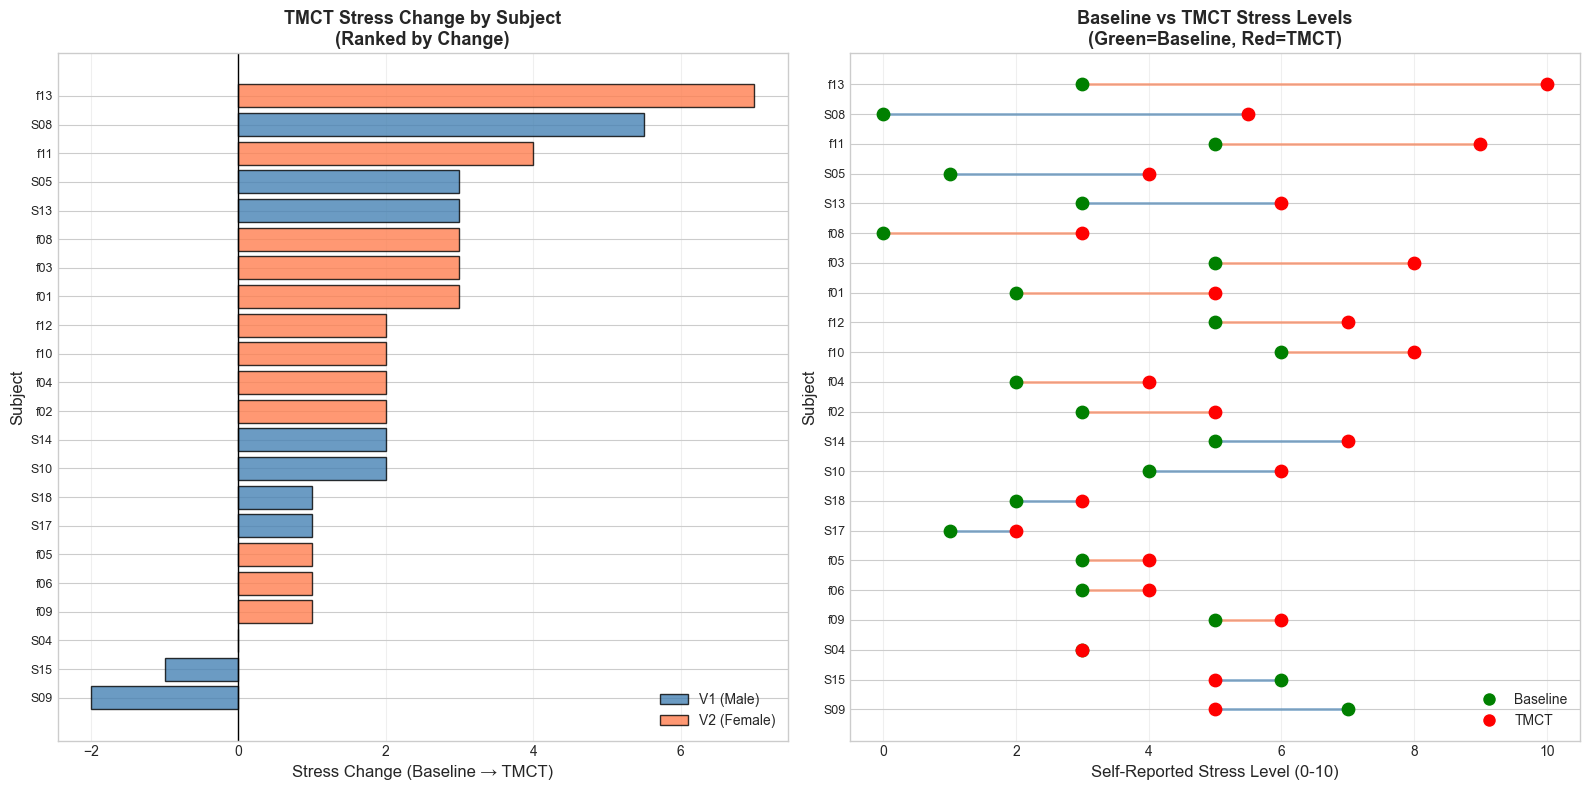

In [8]:
# Visualize TMCT stress changes
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Horizontal bar chart of stress changes (ranked)
colors = ['steelblue' if p == 'V1 (Male)' else 'coral' for p in df_changes_sorted['Protocol']]
y_pos = range(len(df_changes_sorted))

axes[0].barh(y_pos, df_changes_sorted['Change'], color=colors, alpha=0.8, edgecolor='black')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(df_changes_sorted['Subject'], fontsize=9)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Stress Change (Baseline → TMCT)', fontsize=12)
axes[0].set_ylabel('Subject', fontsize=12)
axes[0].set_title('TMCT Stress Change by Subject\n(Ranked by Change)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.8, edgecolor='black', label='V1 (Male)'),
    Patch(facecolor='coral', alpha=0.8, edgecolor='black', label='V2 (Female)')
]
axes[0].legend(handles=legend_elements, loc='lower right')

# Plot 2: Before/After comparison (lollipop chart)
df_sorted_by_subject = df_changes.sort_values('Change', ascending=False)
subjects = df_sorted_by_subject['Subject'].tolist()
y_pos2 = range(len(subjects))

for i, (_, row) in enumerate(df_sorted_by_subject.iterrows()):
    color = 'steelblue' if row['Protocol'] == 'V1 (Male)' else 'coral'
    # Draw line connecting baseline to TMCT
    axes[1].plot([row['Baseline'], row['TMCT']], [i, i], color=color, linewidth=2, alpha=0.6)
    # Draw baseline point
    axes[1].scatter(row['Baseline'], i, color='green', s=80, zorder=5, label='Baseline' if i == 0 else '')
    # Draw TMCT point  
    axes[1].scatter(row['TMCT'], i, color='red', s=80, zorder=5, label='TMCT' if i == 0 else '')

axes[1].set_yticks(y_pos2)
axes[1].set_yticklabels(subjects, fontsize=9)
axes[1].set_xlabel('Self-Reported Stress Level (0-10)', fontsize=12)
axes[1].set_ylabel('Subject', fontsize=12)
axes[1].set_title('Baseline vs TMCT Stress Levels\n(Green=Baseline, Red=TMCT)', fontsize=13, fontweight='bold')
axes[1].set_xlim(-0.5, 10.5)
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].invert_yaxis()

# Add legend for points
from matplotlib.lines import Line2D
legend_elements2 = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Baseline'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='TMCT')
]
axes[1].legend(handles=legend_elements2, loc='lower right')

plt.tight_layout()
plt.show()

---
## Load Physiological Signals

In [9]:
def create_df_array(dataframe):
    return dataframe.values.flatten()

def time_abs_(UTC_array):
    new_array = []
    start_time = datetime.datetime.strptime(UTC_array[0], '%Y-%m-%d %H:%M:%S')
    for utc in UTC_array:
        current_time = datetime.datetime.strptime(utc, '%Y-%m-%d %H:%M:%S')
        seconds_elapsed = (current_time - start_time).total_seconds()
        new_array.append(int(seconds_elapsed))
    return new_array

def moving_average(acc_data):
    avg = 0
    prevX, prevY, prevZ = 0, 0, 0
    results = []
    for i in range(0, len(acc_data), 32):
        sum_ = 0
        buffX = acc_data[i:i+32, 0]
        buffY = acc_data[i:i+32, 1]
        buffZ = acc_data[i:i+32, 2]
        for j in range(len(buffX)):
            sum_ += max(abs(buffX[j] - prevX), abs(buffY[j] - prevY), abs(buffZ[j] - prevZ))
            prevX, prevY, prevZ = buffX[j], buffY[j], buffZ[j]
        avg = avg * 0.9 + (sum_ / 32) * 0.1
        results.append(avg)
    return results

print("Helper functions defined")

Helper functions defined


In [10]:
def read_signals(main_folder):
    signal_dict = {}
    time_dict = {}
    fs_dict = {}
    
    subfolders = next(os.walk(main_folder))[1]
    
    utc_start_dict = {}
    for folder_name in subfolders:
        csv_path = f'{main_folder}/{folder_name}/EDA.csv'
        df = pd.read_csv(csv_path)
        utc_start_dict[folder_name] = df.columns.tolist()
    
    for folder_name in subfolders:
        folder_path = os.path.join(main_folder, folder_name)
        files = os.listdir(folder_path)
        
        signals = {}
        time_line = {}
        fs_signal = {}
        
        desired_files = ['EDA.csv', 'BVP.csv', 'HR.csv', 'TEMP.csv', 'tags.csv', 'ACC.csv', 'IBI.csv']
        
        for file_name in files:
            if file_name not in desired_files:
                continue
            
            file_path = os.path.join(folder_path, file_name)
            signal_name = file_name.replace('.csv', '')
            
            if file_name == 'tags.csv':
                try:
                    df = pd.read_csv(file_path, header=None)
                    tags_vector = create_df_array(df)
                    tags_UTC_vector = np.insert(tags_vector, 0, utc_start_dict[folder_name])
                    signal_array = time_abs_(tags_UTC_vector)
                except pd.errors.EmptyDataError:
                    signal_array = []
            elif file_name == 'IBI.csv':
                df = pd.read_csv(file_path)
                signal_array = df.values
                fs_signal['IBI'] = 'variable'
            else:
                df = pd.read_csv(file_path)
                fs = int(df.iloc[0, 0])
                signal_array = df.iloc[1:].values
                time_array = np.linspace(0, len(signal_array)/fs, len(signal_array))
                time_line[signal_name] = time_array
                fs_signal[signal_name] = fs
            
            signals[signal_name] = signal_array
        
        signal_dict[folder_name] = signals
        time_dict[folder_name] = time_line
        fs_dict[folder_name] = fs_signal
    
    return signal_dict, time_dict, fs_dict

# Load all signals
print("Loading physiological signals...")
signal_data, time_data, fs_dict = read_signals(dataset_path)
print(f"Loaded {len(signal_data)} subjects: {sorted(signal_data.keys())}")

Loading physiological signals...
Loaded 22 subjects: ['S04', 'S05', 'S08', 'S09', 'S10', 'S13', 'S14', 'S15', 'S17', 'S18', 'f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f08', 'f09', 'f10', 'f11', 'f12', 'f13']


---
## Plot Body Signals for All 22 Subjects

In [11]:
# Signal colors
SIGNAL_COLORS = {
    'BVP': '#e74c3c',
    'HR': '#3498db',
    'ACC': '#e67e22'
}

# Highlight only TMCT phase
PHASE_COLORS = {
    'TMCT': '#e67e22'
}

def get_stress_rest_segments(subject_id, tags):
    """Get protocol segments with phase labels."""
    segments = []
    
    if subject_id.startswith('S'):  # V1 protocol
        if len(tags) >= 13:
            segments.append({'start': tags[0], 'end': tags[3], 'label': 'REST', 'phase': 'Baseline'})
            segments.append({'start': tags[3], 'end': tags[4], 'label': 'STRESS', 'phase': 'Stroop'})
            segments.append({'start': tags[4], 'end': tags[5], 'label': 'REST', 'phase': 'First Rest'})
            segments.append({'start': tags[5], 'end': tags[6], 'label': 'STRESS', 'phase': 'TMCT'})
            segments.append({'start': tags[6], 'end': tags[7], 'label': 'REST', 'phase': 'Second Rest'})
            segments.append({'start': tags[7], 'end': tags[8], 'label': 'STRESS', 'phase': 'Real Opinion'})
            segments.append({'start': tags[8], 'end': tags[9], 'label': 'REST', 'phase': 'Transition Rest 1'})
            segments.append({'start': tags[9], 'end': tags[10], 'label': 'STRESS', 'phase': 'Opposite Opinion'})
            segments.append({'start': tags[10], 'end': tags[11], 'label': 'REST', 'phase': 'Transition Rest 2'})
            segments.append({'start': tags[11], 'end': tags[12], 'label': 'STRESS', 'phase': 'Subtract'})
    else:  # V2 protocol
        if len(tags) >= 10:
            segments.append({'start': tags[0], 'end': tags[2], 'label': 'REST', 'phase': 'Baseline'})
            segments.append({'start': tags[2], 'end': tags[3], 'label': 'STRESS', 'phase': 'TMCT'})
            segments.append({'start': tags[3], 'end': tags[4], 'label': 'REST', 'phase': 'First Rest'})
            segments.append({'start': tags[4], 'end': tags[5], 'label': 'STRESS', 'phase': 'Real Opinion'})
            segments.append({'start': tags[5], 'end': tags[6], 'label': 'REST', 'phase': 'Transition Rest'})
            segments.append({'start': tags[6], 'end': tags[7], 'label': 'STRESS', 'phase': 'Opposite Opinion'})
            segments.append({'start': tags[7], 'end': tags[8], 'label': 'REST', 'phase': 'Second Rest'})
            segments.append({'start': tags[8], 'end': tags[9], 'label': 'STRESS', 'phase': 'Subtract'})
    
    return segments

def plot_subject_signals(subject_id, signals, time_dict, tags):
    """
    Plot BVP, HR, ACC signals for one subject with TMCT phase highlighted.
    """
    protocol = "V1 (Male, with Stroop)" if subject_id.startswith('S') else "V2 (Female, without Stroop)"
    segments = get_stress_rest_segments(subject_id, tags)
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle(f'{subject_id} - {protocol}', fontsize=14, fontweight='bold', y=1.01)
    
    signal_names = ['BVP', 'HR', 'ACC']
    signal_labels = [
        'BVP (Blood Volume Pulse)',
        'HR (Heart Rate)',
        'ACC (Movement)'
    ]
    
    for ax, signal_name, signal_label in zip(axes, signal_names, signal_labels):
        # Plot signal
        if signal_name in signals and signal_name in time_dict:
            if signal_name == 'ACC':
                acc_filtered = moving_average(signals[signal_name])
                time_acc = np.linspace(0, len(signals[signal_name])/32, len(acc_filtered))
                ax.plot(time_acc, acc_filtered, color=SIGNAL_COLORS[signal_name], linewidth=0.8)
            else:
                ax.plot(time_dict[signal_name], signals[signal_name], 
                       color=SIGNAL_COLORS[signal_name], linewidth=0.5)
        
        # Highlight ONLY TMCT phase
        for seg in segments:
            if seg['phase'] == 'TMCT':
                ax.axvspan(seg['start'], seg['end'], 
                          color=PHASE_COLORS['TMCT'], alpha=0.3)
        
        ax.set_ylabel(signal_name, fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time (seconds)', fontsize=11)
    
    # Add legend for signals and TMCT phase
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    
    legend_elements = []
    # Signals
    legend_elements.append(Line2D([0], [0], color='none', label='Signals:'))
    for s, l in zip(signal_names, signal_labels):
        legend_elements.append(Line2D([0], [0], color=SIGNAL_COLORS[s], linewidth=2, label=f'  {l}'))
    
    # TMCT phase only
    legend_elements.append(Patch(facecolor='none', edgecolor='none', label=''))
    legend_elements.append(Patch(facecolor='none', edgecolor='none', label='Highlighted Phase:'))
    legend_elements.append(Patch(facecolor=PHASE_COLORS['TMCT'], alpha=0.5, label='  TMCT'))
    
    fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.01, 0.5),
               fontsize=9, title='Legend', title_fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(right=0.82)
    plt.show()

print("Plotting function defined")

Plotting function defined


### V1 Subjects (Males with Stroop Test)

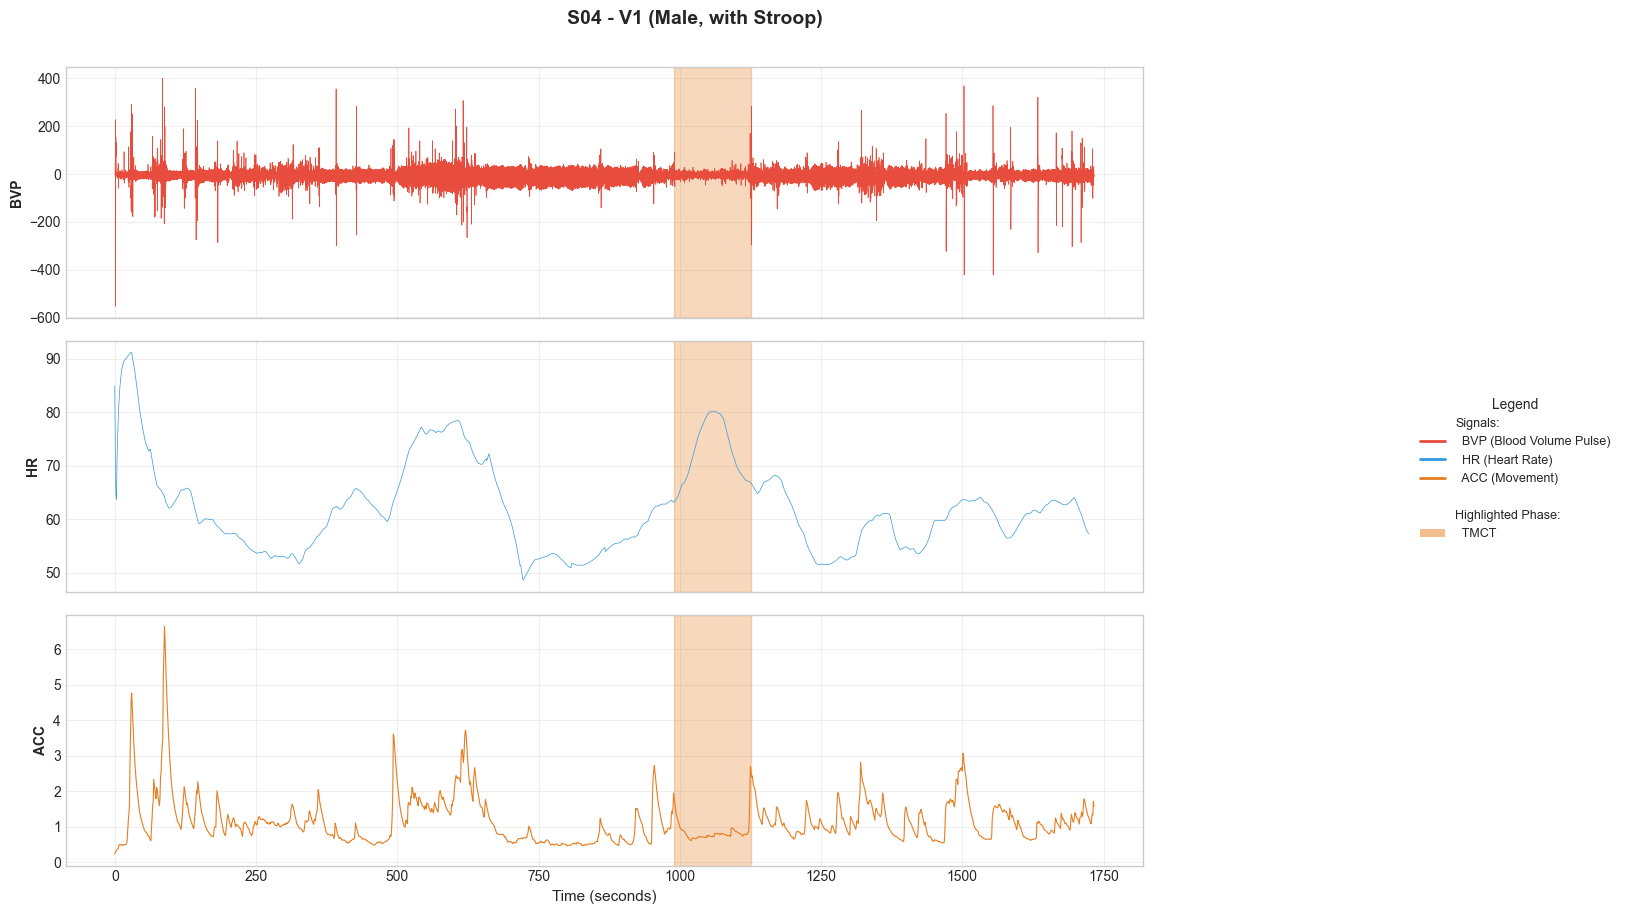

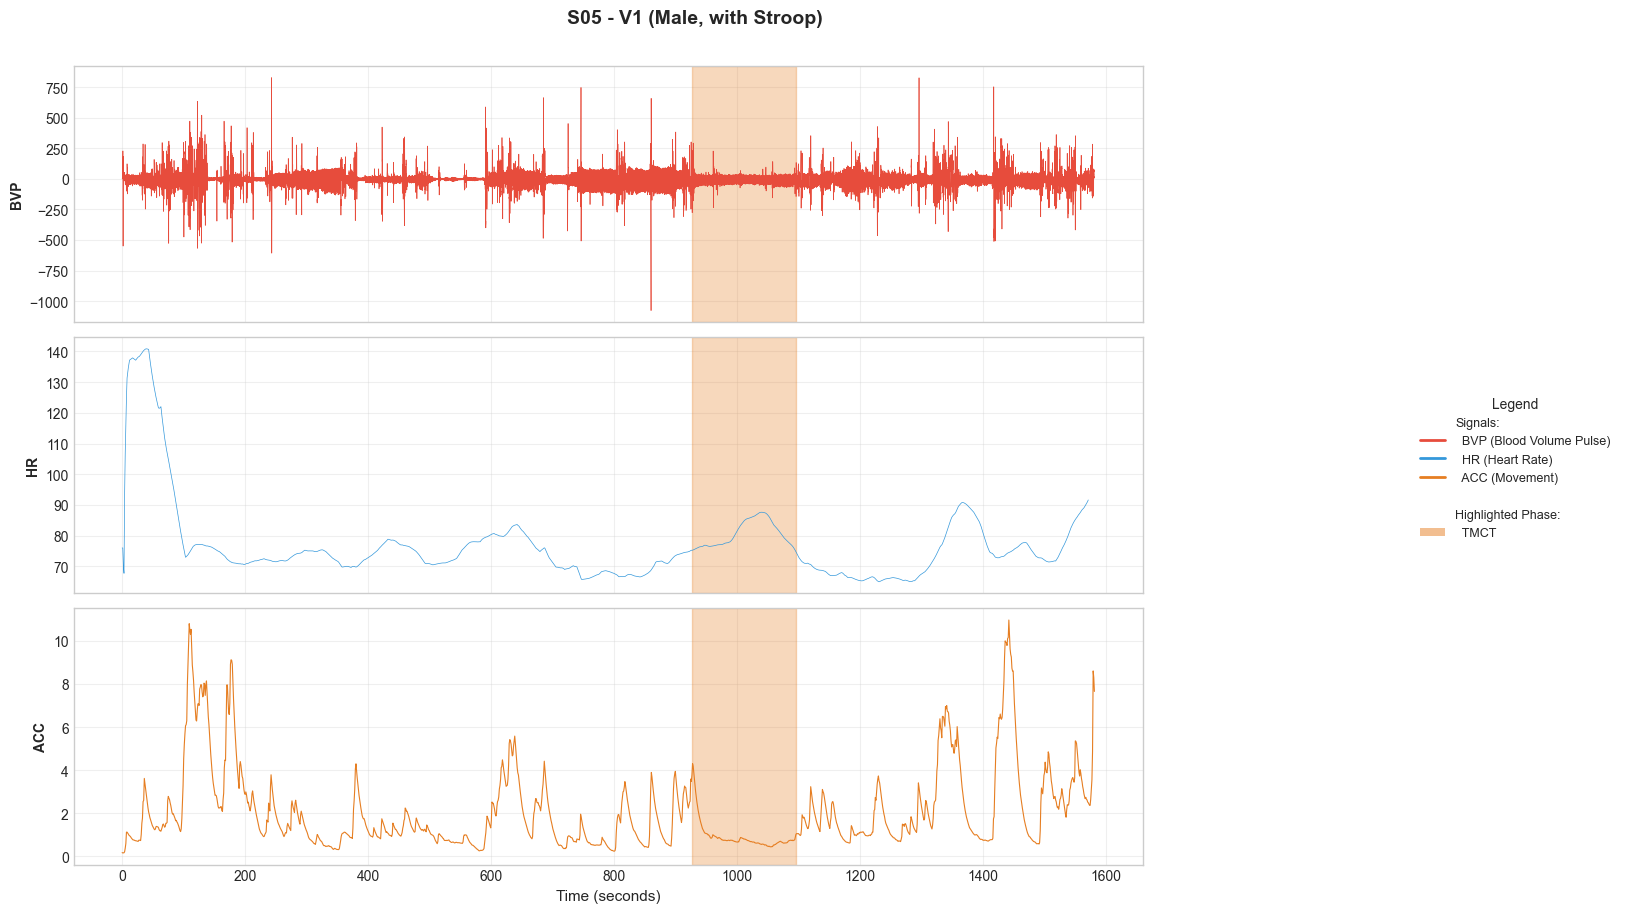

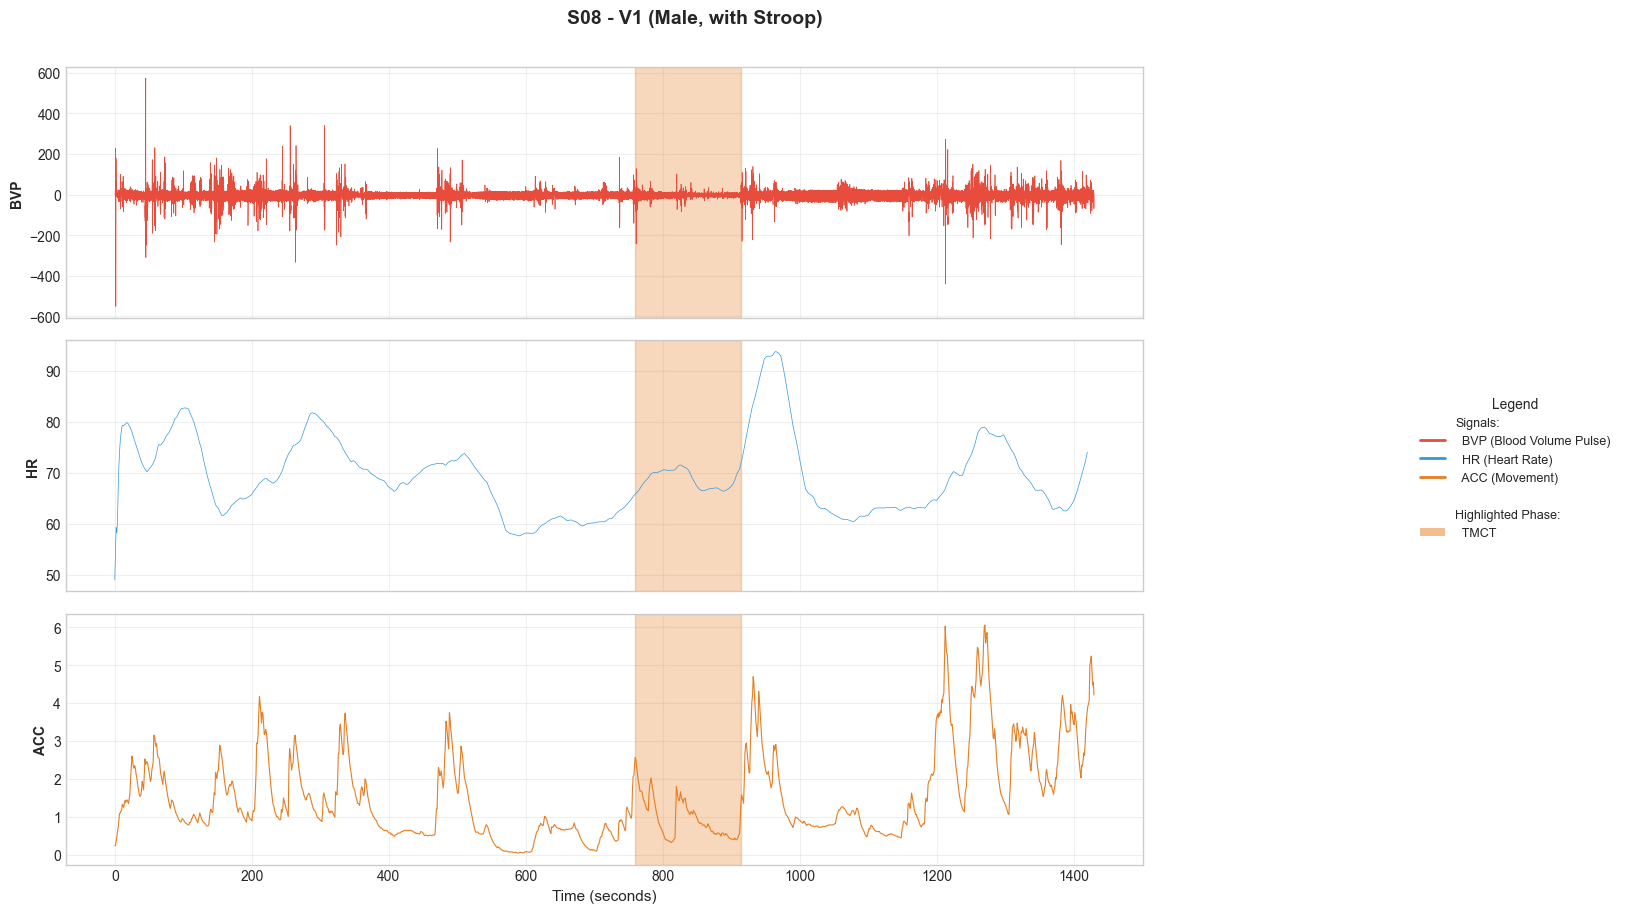

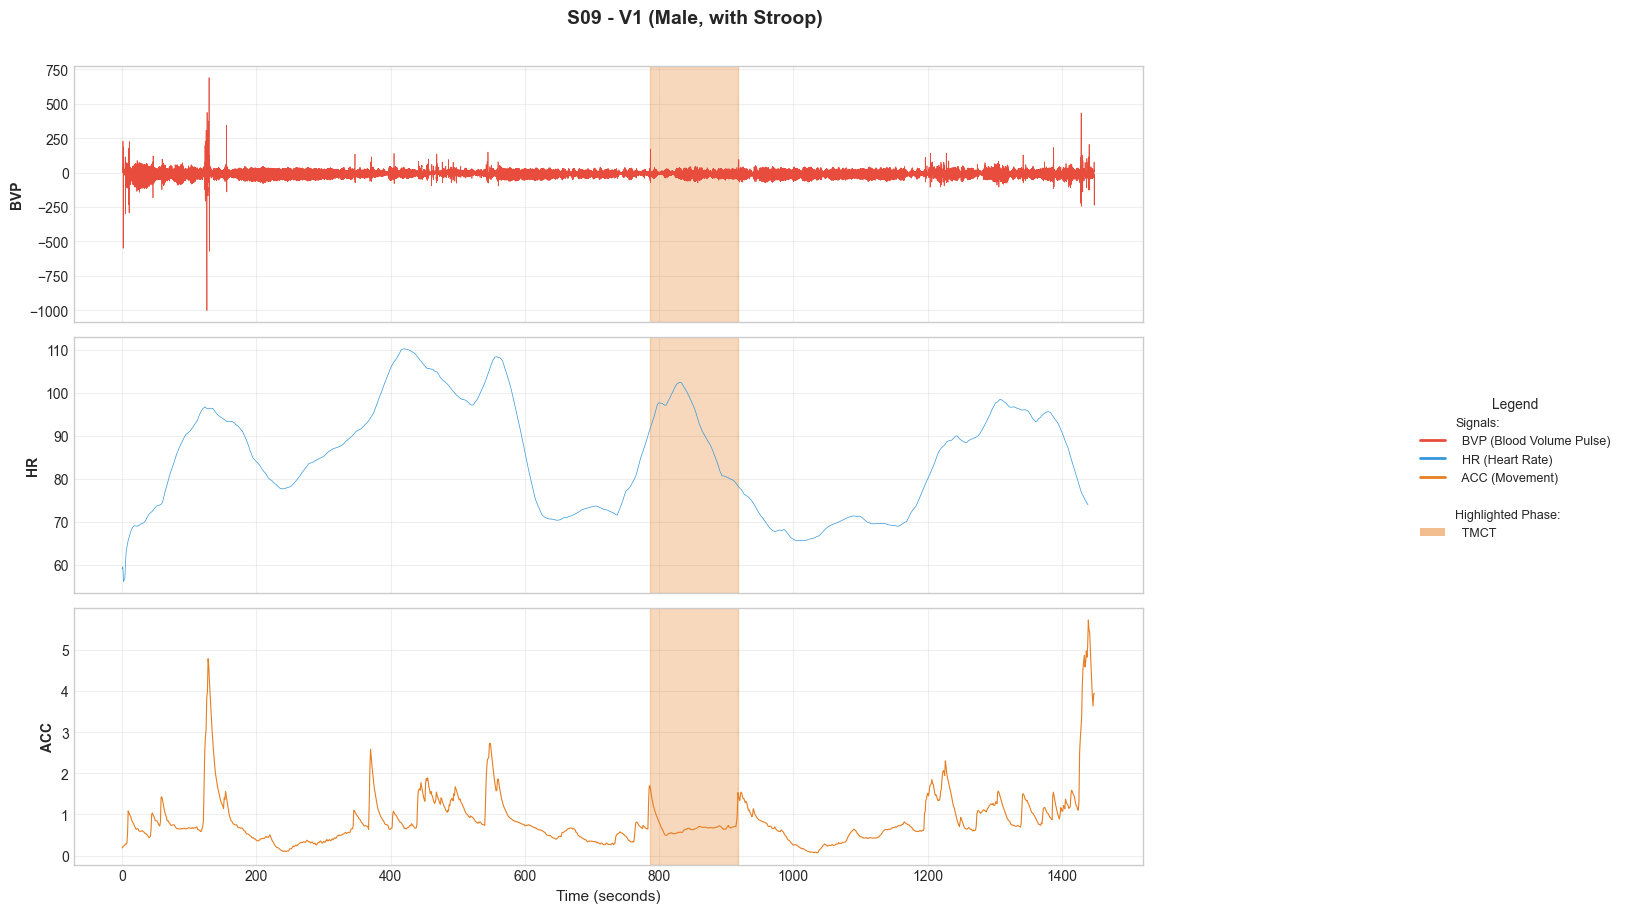

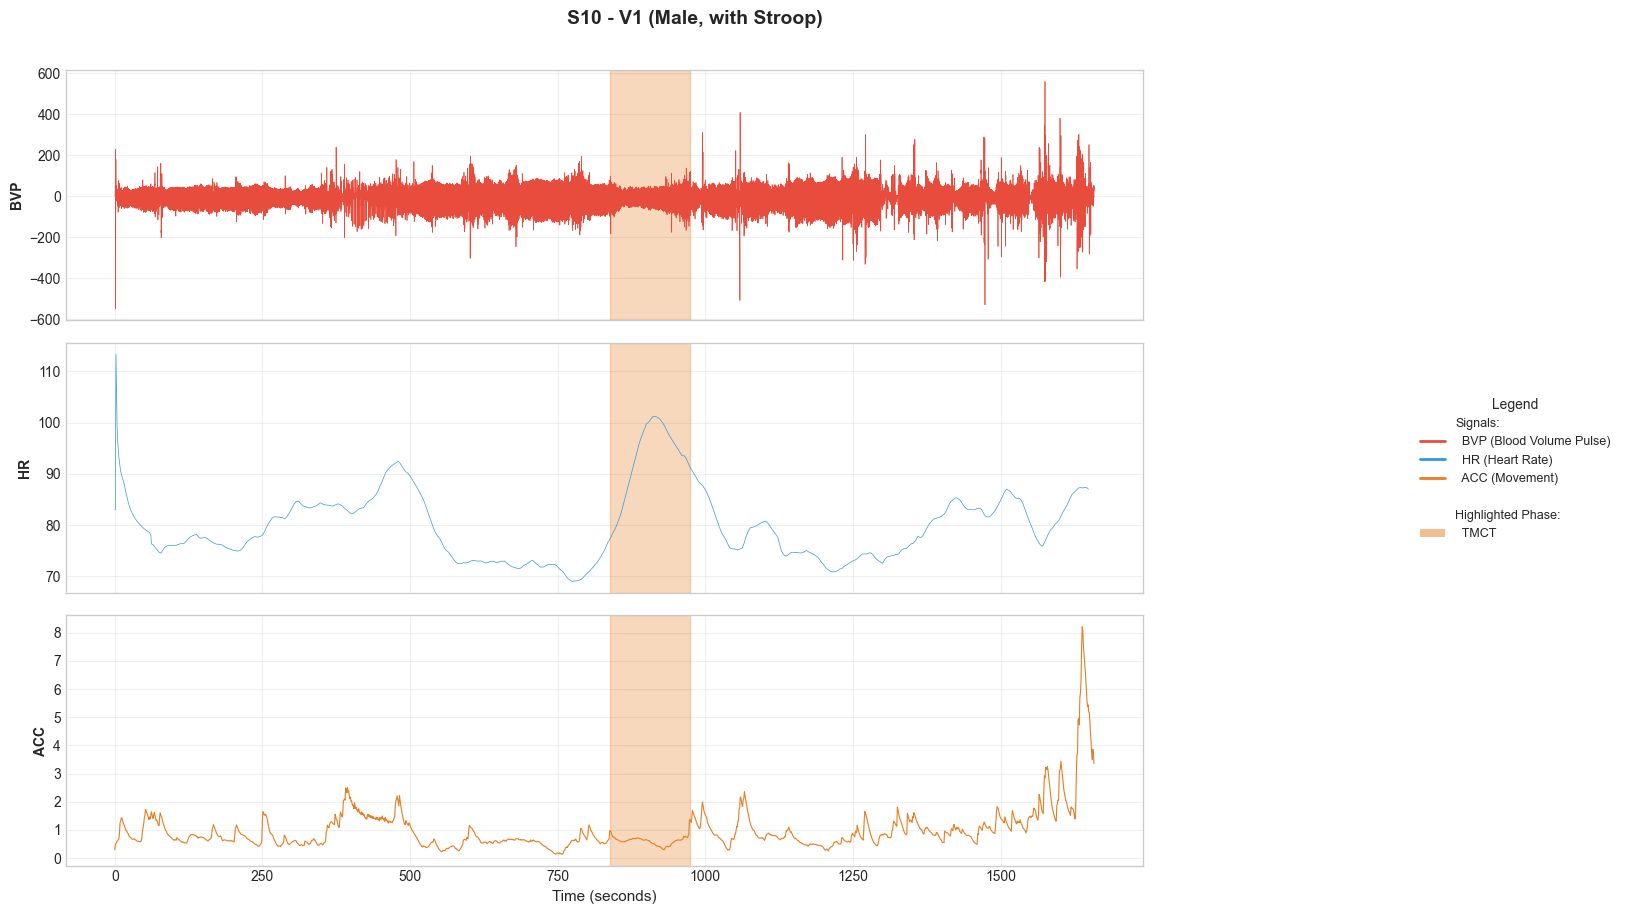

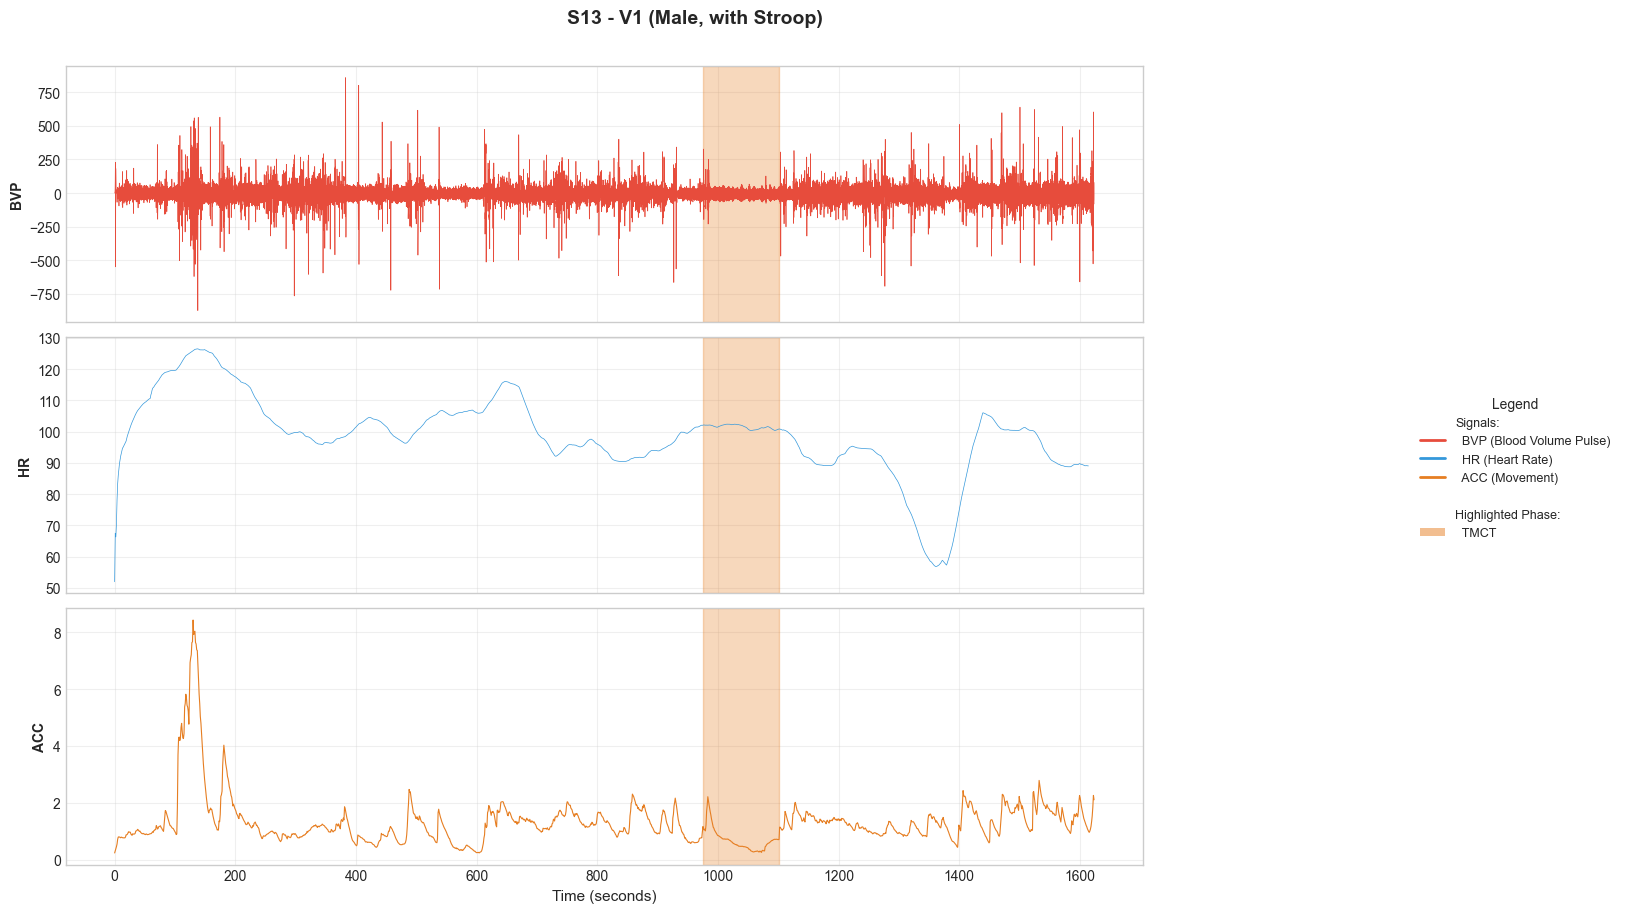

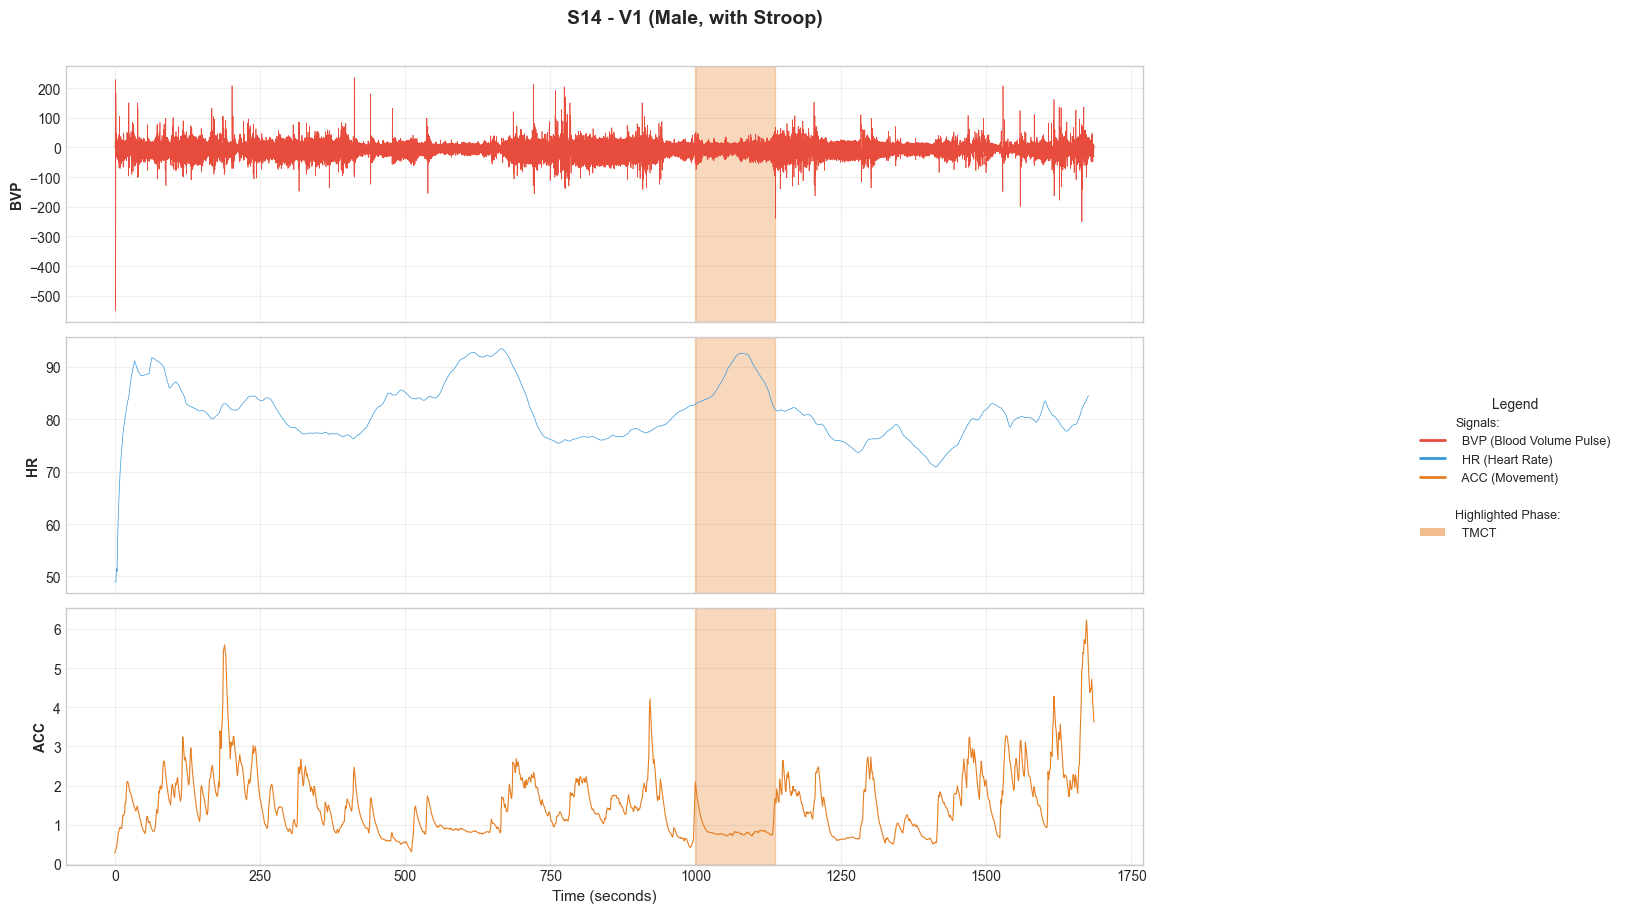

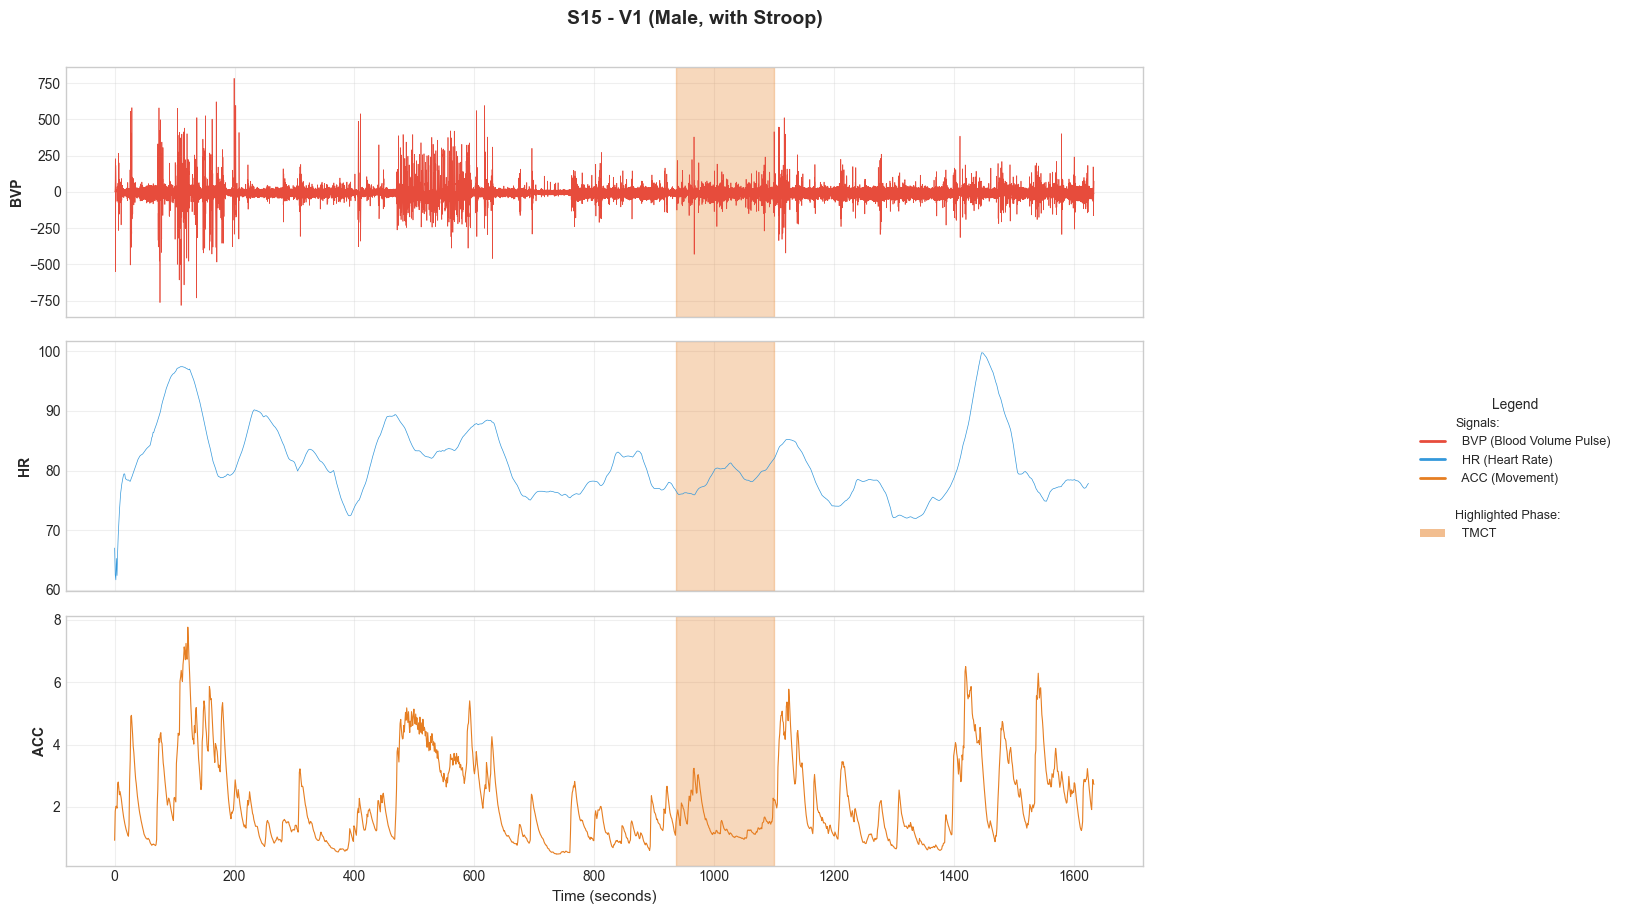

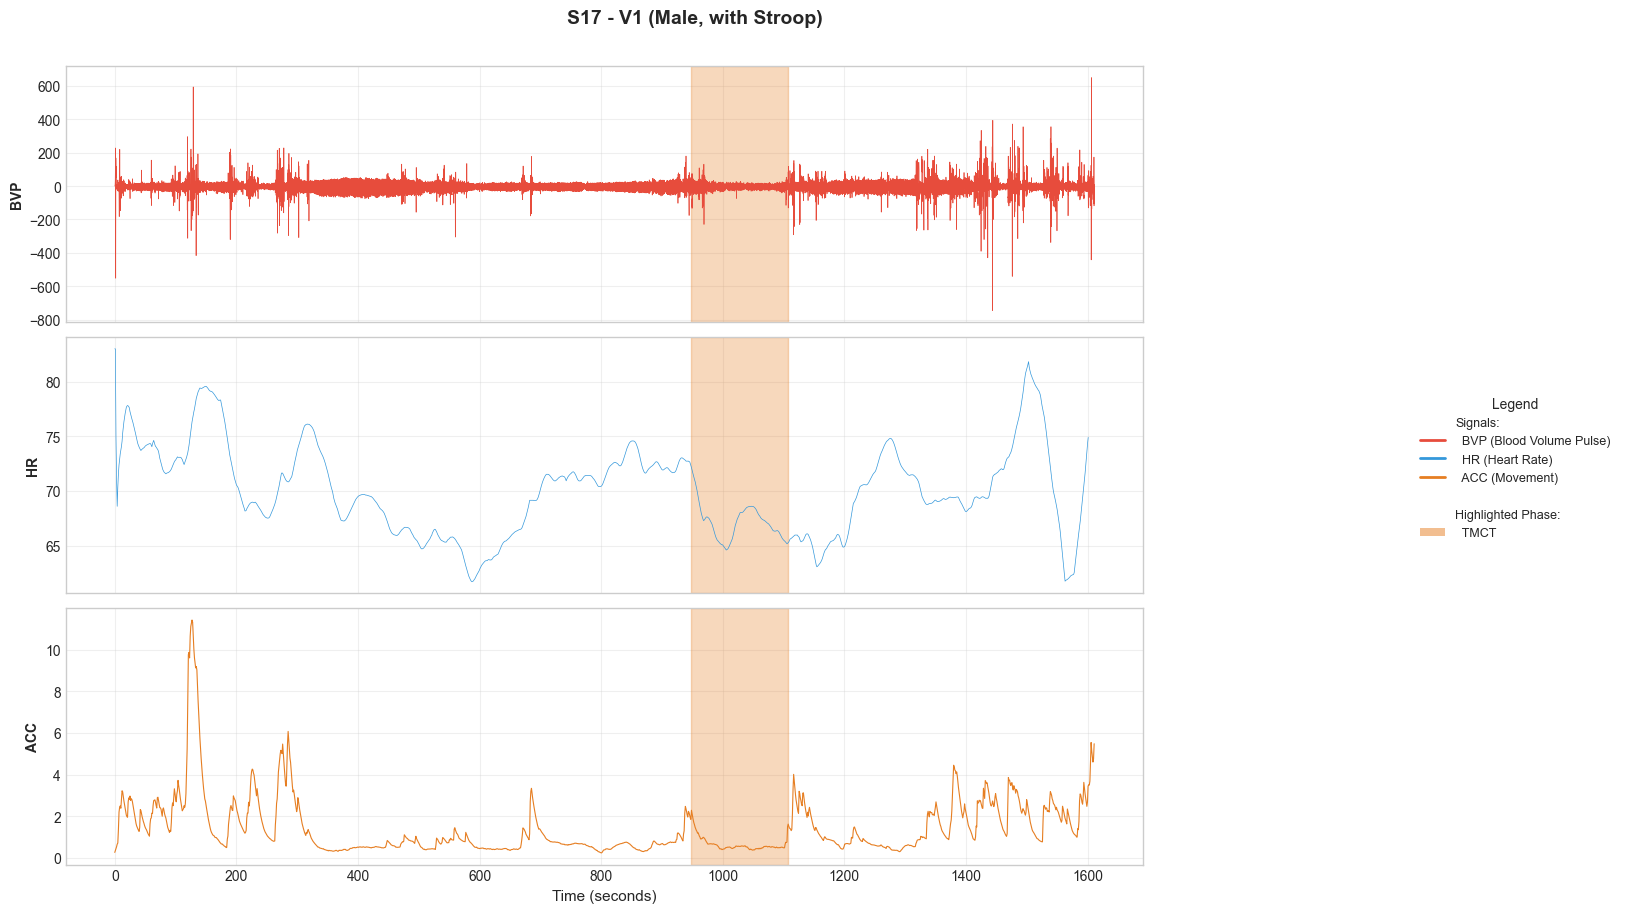

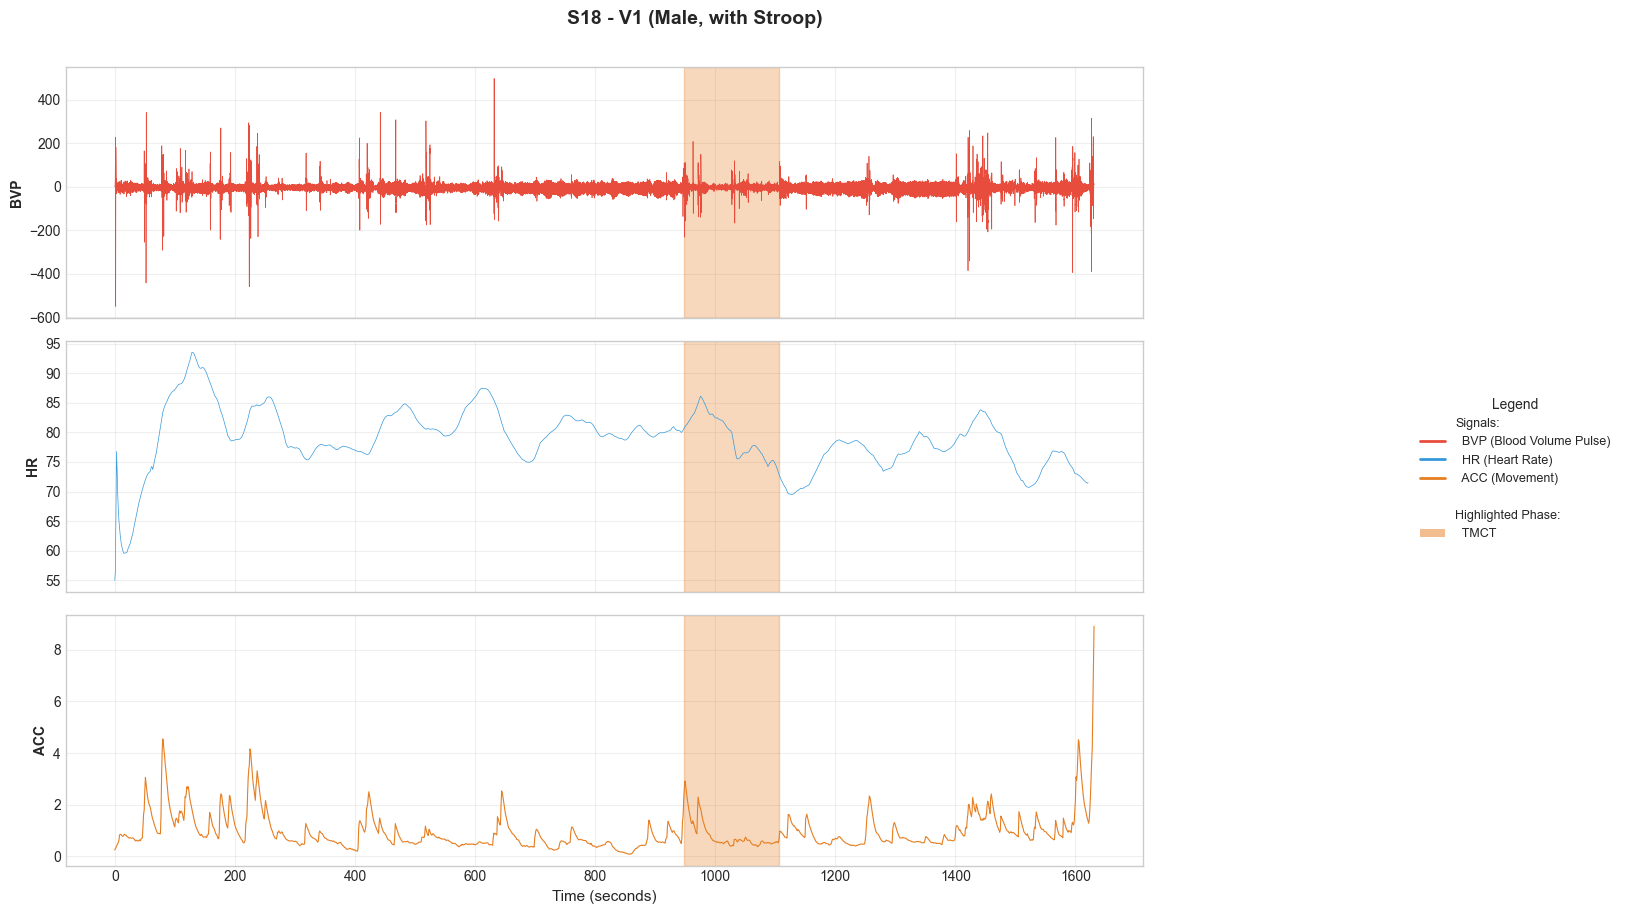

In [12]:
for subject_id in v1_subjects:
    if subject_id in signal_data:
        plot_subject_signals(
            subject_id,
            signal_data[subject_id],
            time_data[subject_id],
            signal_data[subject_id]['tags']
        )
    else:
        print(f"WARNING: {subject_id} not found!")

### V2 Subjects (Females without Stroop Test)

---
## Verify Time Segments for All Subjects

In [13]:
# Check tags and segments for all subjects
print("=" * 80)
print("TAG AND SEGMENT VERIFICATION")
print("=" * 80)

for subject_id in all_subjects:
    if subject_id not in signal_data:
        print(f"\n{subject_id}: NOT FOUND IN DATA")
        continue
    
    tags = signal_data[subject_id]['tags']
    protocol = "V1 (Male)" if subject_id.startswith('S') else "V2 (Female)"
    expected_tags = 13 if subject_id.startswith('S') else 10
    
    print(f"\n{subject_id} - {protocol}")
    print(f"  Number of tags: {len(tags)} (expected: {expected_tags})")
    
    if len(tags) < expected_tags:
        print(f"  ⚠️ WARNING: Insufficient tags! Expected {expected_tags}, got {len(tags)}")
        print(f"  Tags: {tags}")
        continue
    
    # Get segments
    segments = get_stress_rest_segments(subject_id, tags)
    
    # Display stress phases only
    stress_segments = [seg for seg in segments if seg['label'] == 'STRESS']
    print(f"  Stress phases:")
    for seg in stress_segments:
        duration = seg['end'] - seg['start']
        print(f"    {seg['phase']:20s}: {seg['start']:6.0f}s - {seg['end']:6.0f}s  (duration: {duration:5.0f}s)")
    
    # Check for any anomalies
    if any(seg['end'] <= seg['start'] for seg in segments):
        print(f"  ⚠️ WARNING: Found segments with invalid time ranges!")
    
print("\n" + "=" * 80)

TAG AND SEGMENT VERIFICATION

S04 - V1 (Male)
  Number of tags: 14 (expected: 13)
  Stress phases:
    Stroop              :    519s -    615s  (duration:    96s)
    TMCT                :    989s -   1126s  (duration:   137s)
    Real Opinion        :   1470s -   1502s  (duration:    32s)
    Opposite Opinion    :   1553s -   1585s  (duration:    32s)
    Subtract            :   1633s -   1665s  (duration:    32s)

S05 - V1 (Male)
  Number of tags: 14 (expected: 13)
  Stress phases:
    Stroop              :    478s -    590s  (duration:   112s)
    TMCT                :    926s -   1095s  (duration:   169s)
    Real Opinion        :   1322s -   1356s  (duration:    34s)
    Opposite Opinion    :   1417s -   1448s  (duration:    31s)
    Subtract            :   1493s -   1525s  (duration:    32s)

S08 - V1 (Male)
  Number of tags: 14 (expected: 13)
  Stress phases:
    Stroop              :    365s -    470s  (duration:   105s)
    TMCT                :    759s -    914s  (duration:  

In [14]:
# Statistical analysis of phase durations
print("\n" + "=" * 80)
print("PHASE DURATION STATISTICS")
print("=" * 80)

# Collect durations by phase and protocol
v1_durations = {phase: [] for phase in ['Stroop', 'TMCT', 'Real Opinion', 'Opposite Opinion', 'Subtract']}
v2_durations = {phase: [] for phase in ['TMCT', 'Real Opinion', 'Opposite Opinion', 'Subtract']}

for subject_id in all_subjects:
    if subject_id not in signal_data:
        continue
    
    tags = signal_data[subject_id]['tags']
    segments = get_stress_rest_segments(subject_id, tags)
    
    is_v1 = subject_id.startswith('S')
    duration_dict = v1_durations if is_v1 else v2_durations
    
    for seg in segments:
        if seg['label'] == 'STRESS' and seg['phase'] in duration_dict:
            duration = seg['end'] - seg['start']
            duration_dict[seg['phase']].append(duration)

# Display V1 statistics
print("\nV1 Protocol (Males with Stroop):")
print(f"{'Phase':<20} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'N':>4}")
print("-" * 60)
for phase, durations in v1_durations.items():
    if durations:
        print(f"{phase:<20} {np.mean(durations):>8.1f}s {np.std(durations):>7.1f}s {np.min(durations):>7.0f}s {np.max(durations):>7.0f}s {len(durations):>4}")

# Display V2 statistics
print("\nV2 Protocol (Females without Stroop):")
print(f"{'Phase':<20} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'N':>4}")
print("-" * 60)
for phase, durations in v2_durations.items():
    if durations:
        print(f"{phase:<20} {np.mean(durations):>8.1f}s {np.std(durations):>7.1f}s {np.min(durations):>7.0f}s {np.max(durations):>7.0f}s {len(durations):>4}")

# Check for high variability (std > 30% of mean)
print("\n⚠️  Phases with high variability (std > 30% of mean):")
all_durations = {**v1_durations, **v2_durations}
high_var_found = False
for phase, durations in all_durations.items():
    if durations and len(durations) > 1:
        mean_dur = np.mean(durations)
        std_dur = np.std(durations)
        if std_dur > 0.3 * mean_dur:
            print(f"  - {phase}: mean={mean_dur:.1f}s, std={std_dur:.1f}s ({100*std_dur/mean_dur:.0f}% variation)")
            high_var_found = True

if not high_var_found:
    print("  None - all phases have consistent durations!")

print("\n" + "=" * 80)


PHASE DURATION STATISTICS

V1 Protocol (Males with Stroop):
Phase                    Mean      Std      Min      Max    N
------------------------------------------------------------
Stroop                  106.7s     8.0s      92s     117s   10
TMCT                    147.0s    14.3s     127s     169s   10
Real Opinion             31.4s     1.6s      29s      34s   10
Opposite Opinion         30.8s     1.2s      29s      33s   10
Subtract                 32.3s     1.0s      31s      34s   10

V2 Protocol (Females without Stroop):
Phase                    Mean      Std      Min      Max    N
------------------------------------------------------------
TMCT                    285.5s    63.3s     217s     452s   12
Real Opinion             37.9s     3.6s      29s      42s   12
Opposite Opinion         37.4s     3.4s      31s      44s   12
Subtract                 37.7s     5.4s      26s      48s   12

⚠️  Phases with high variability (std > 30% of mean):
  None - all phases have consist

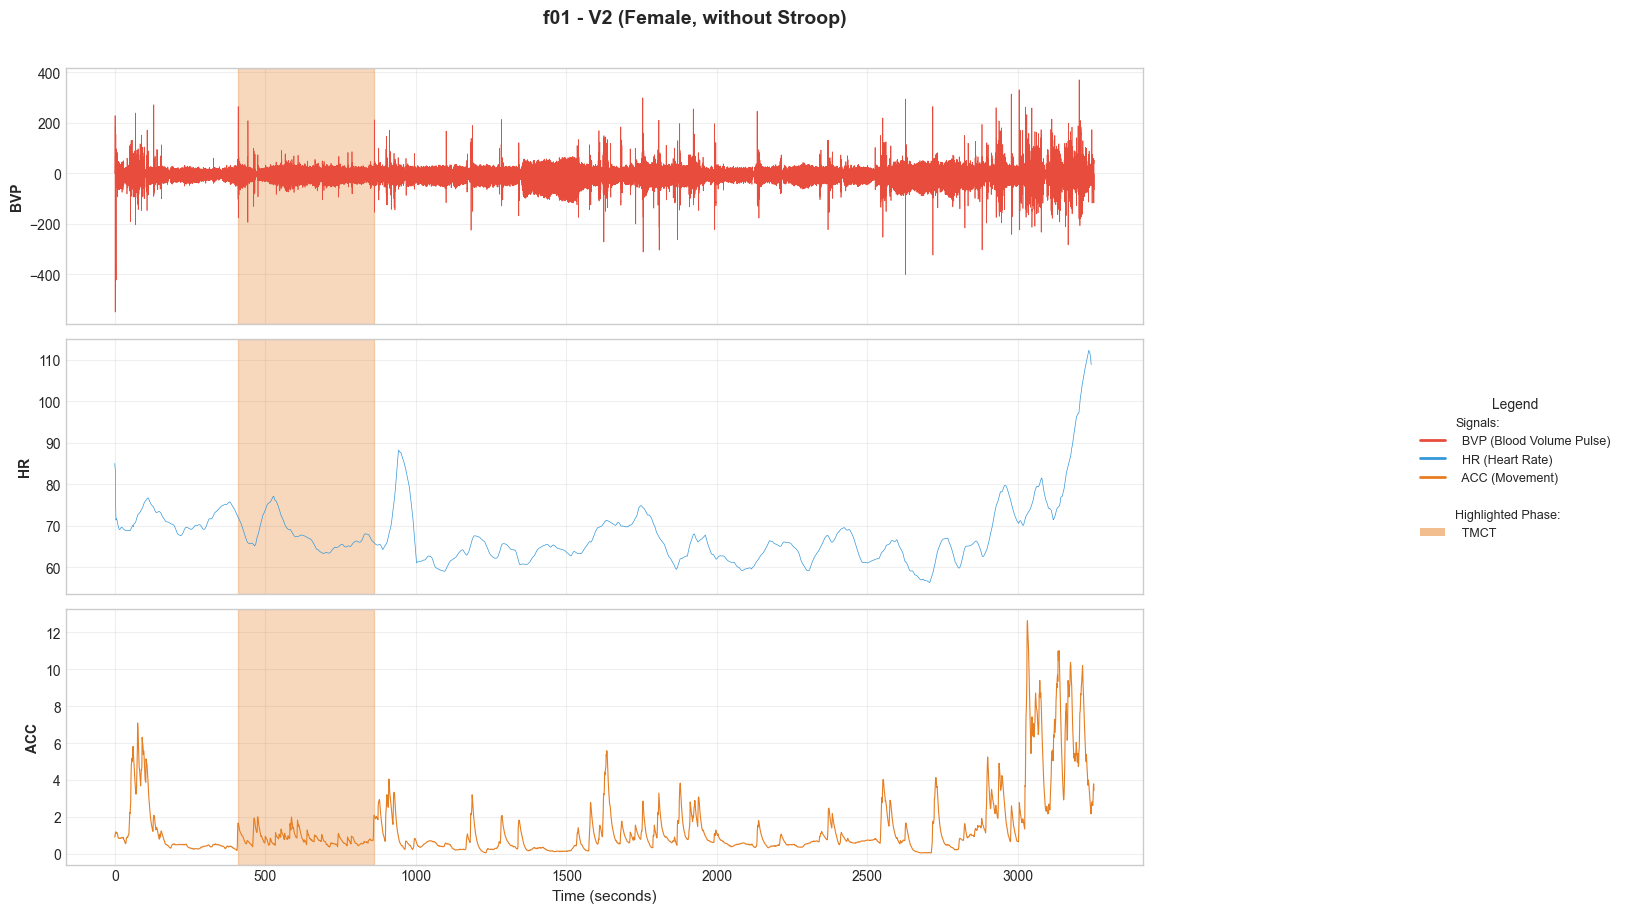

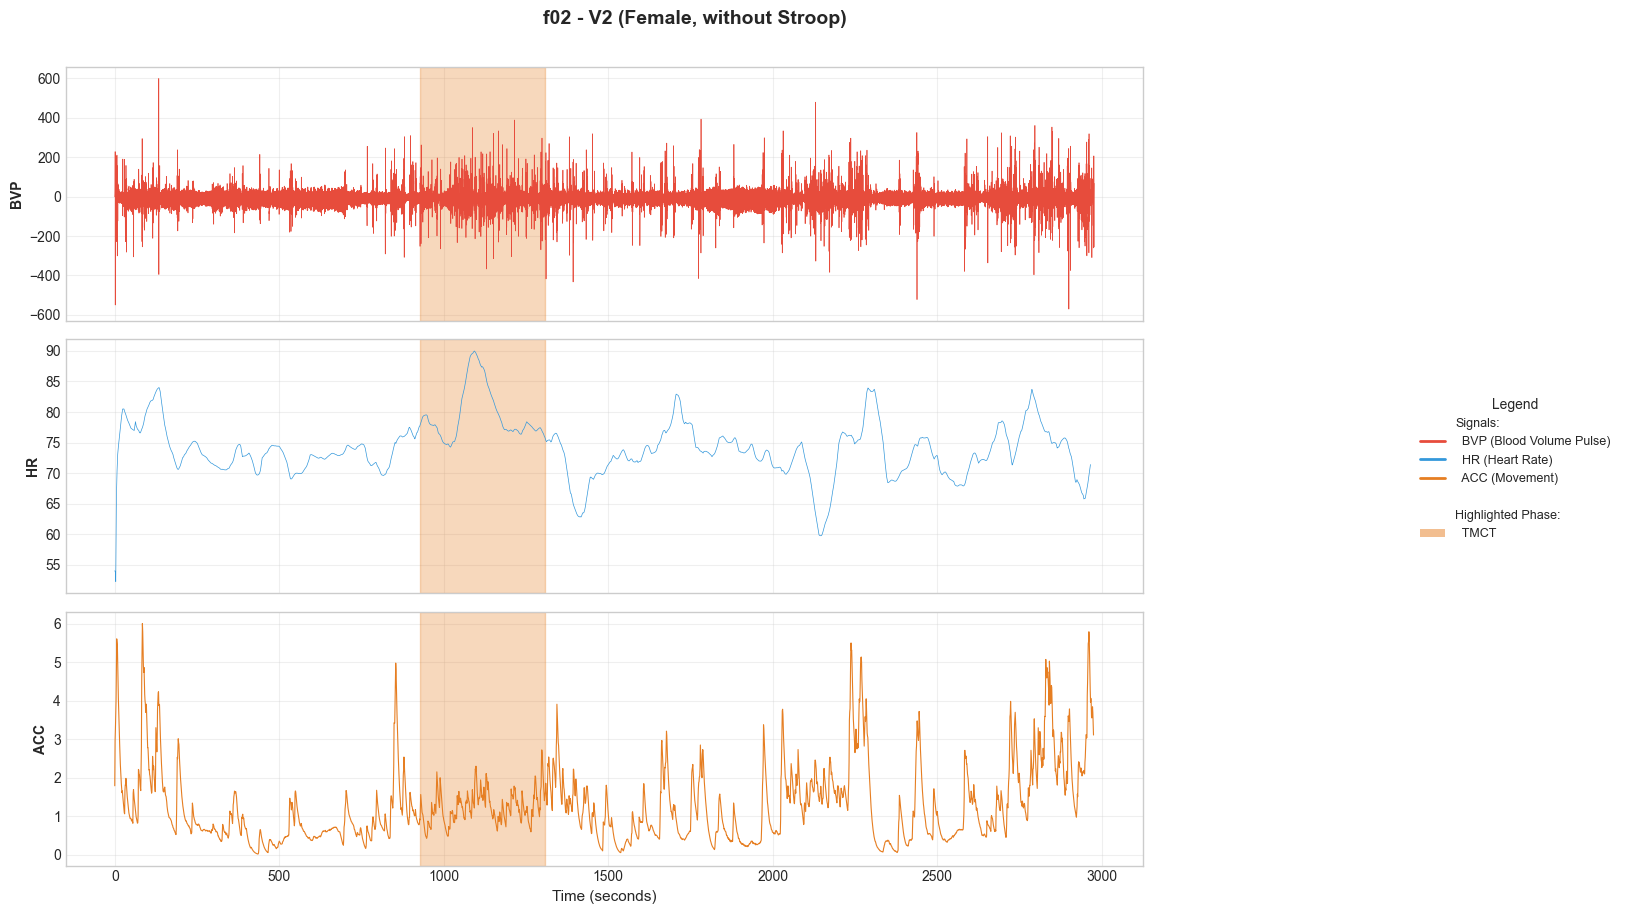

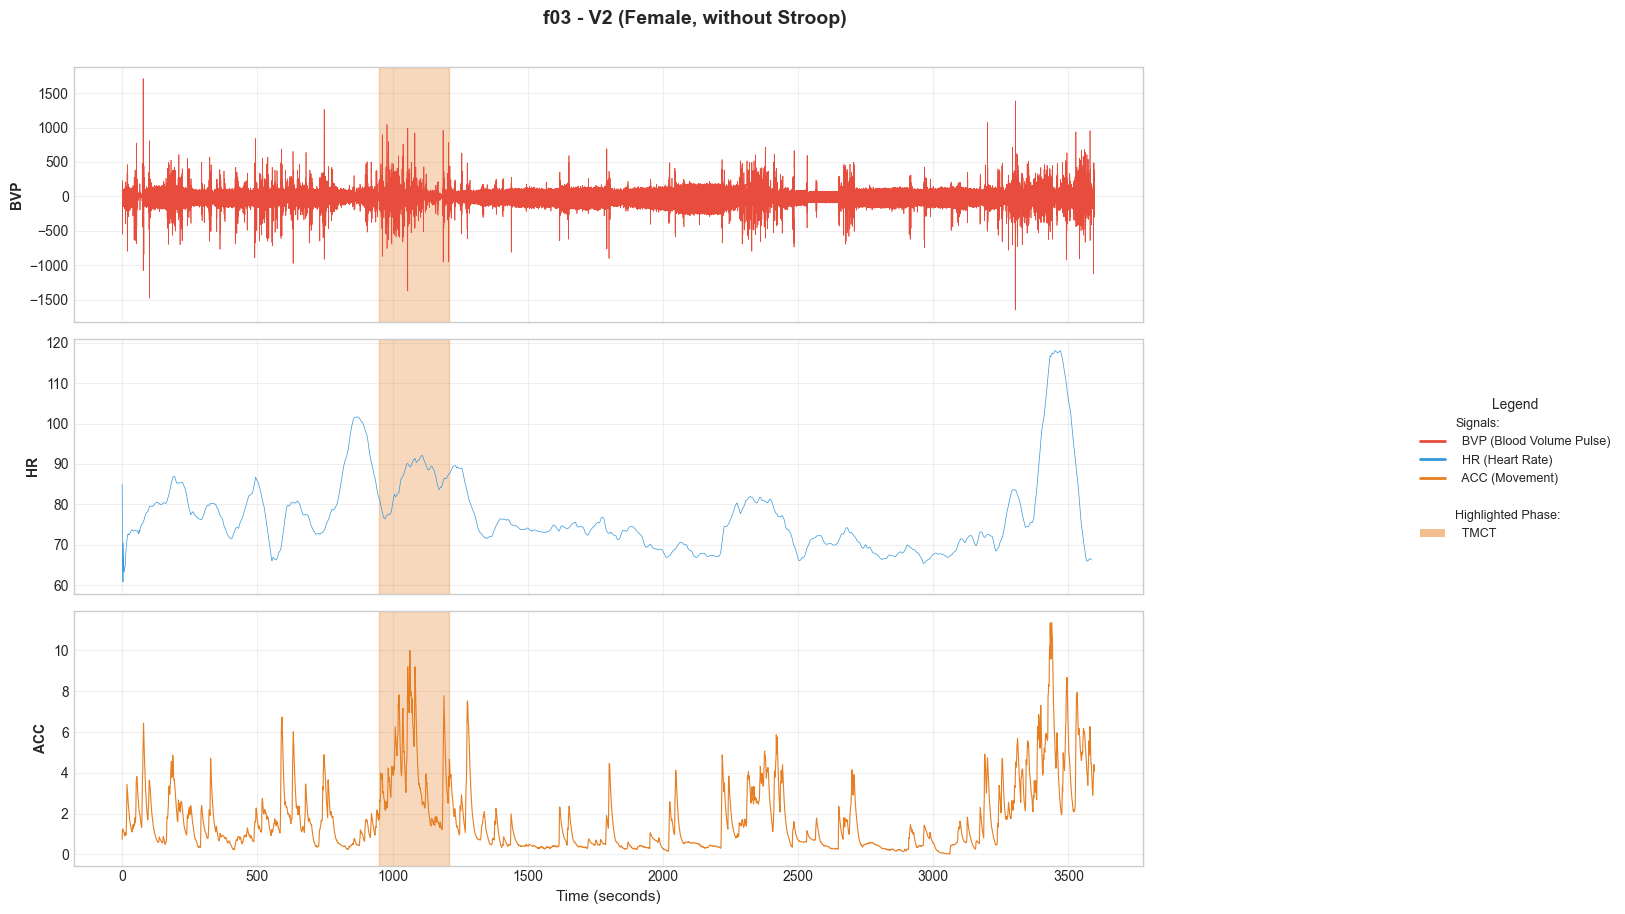

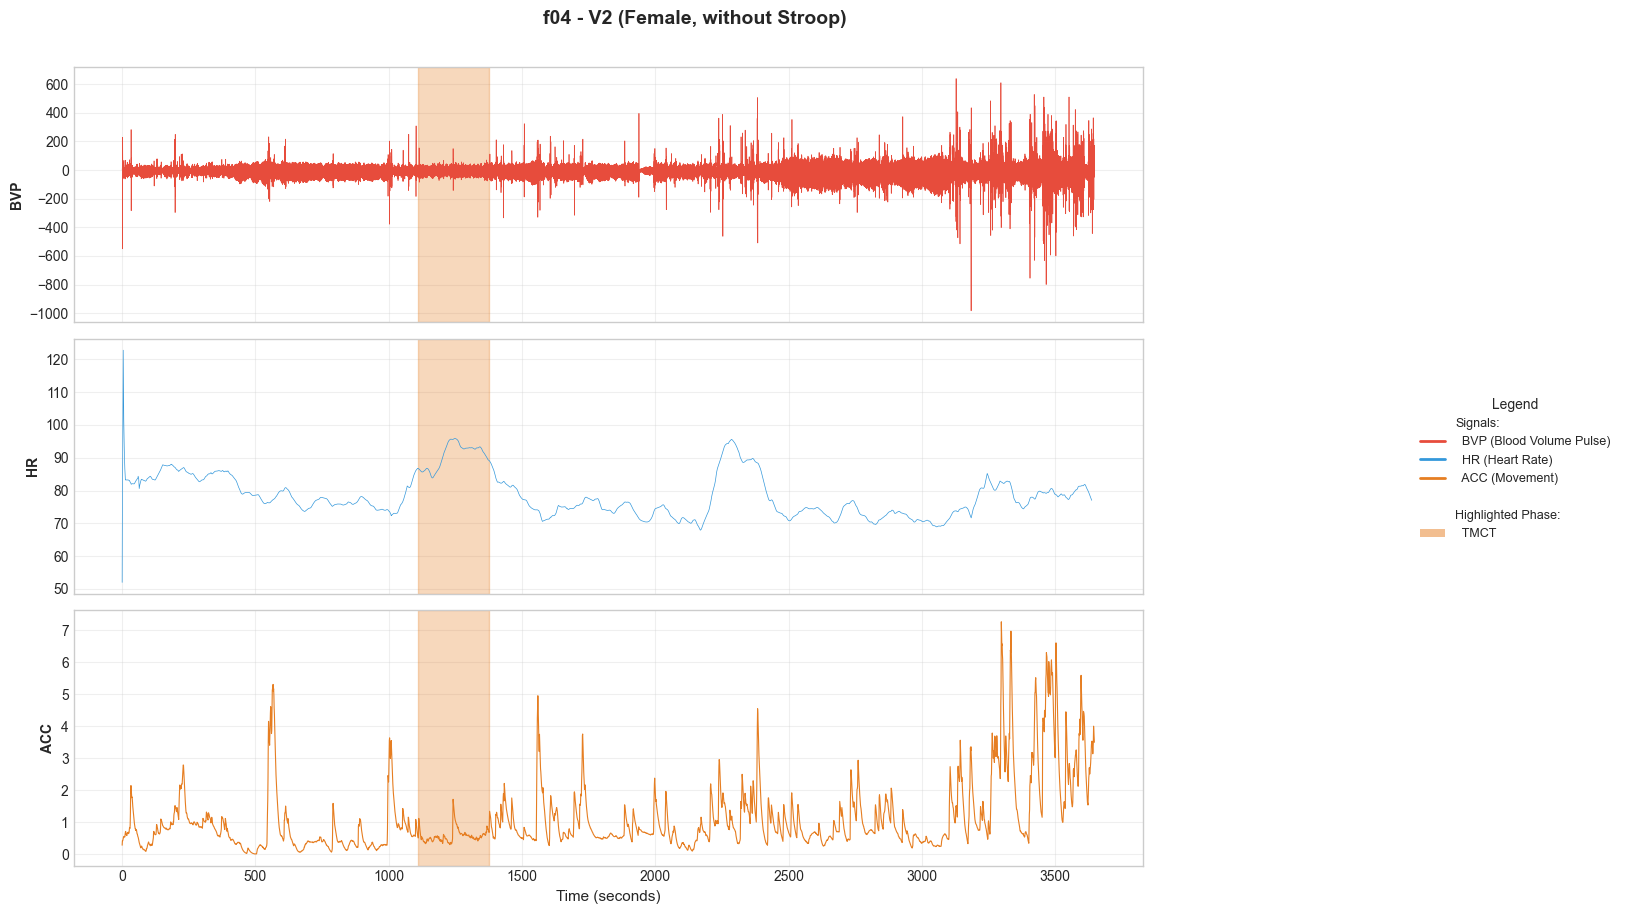

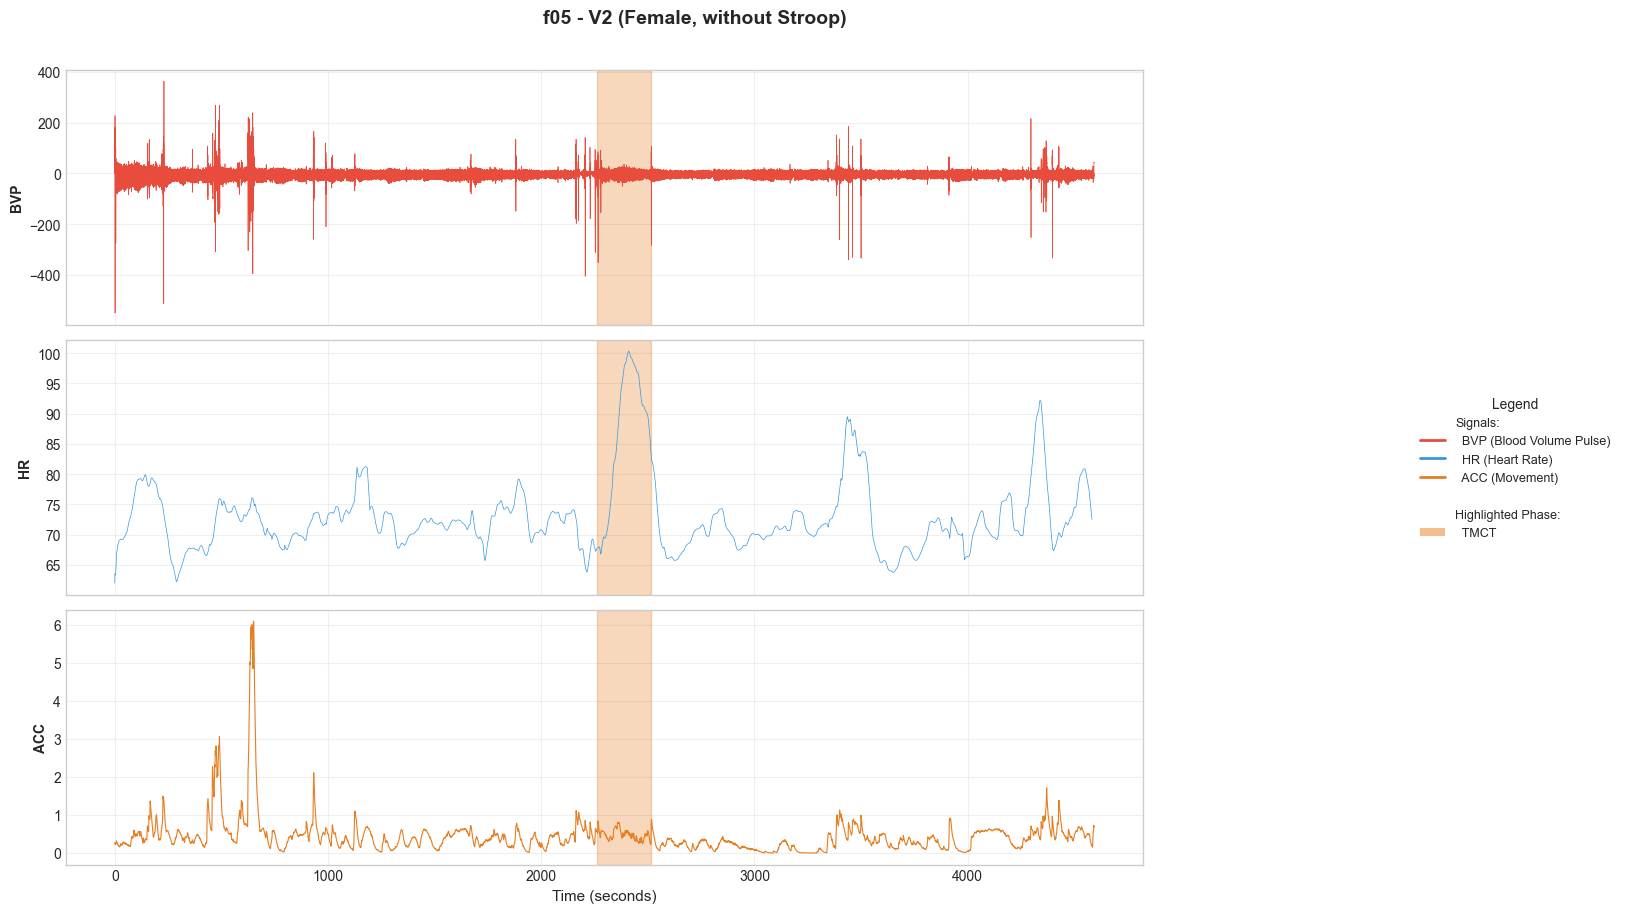

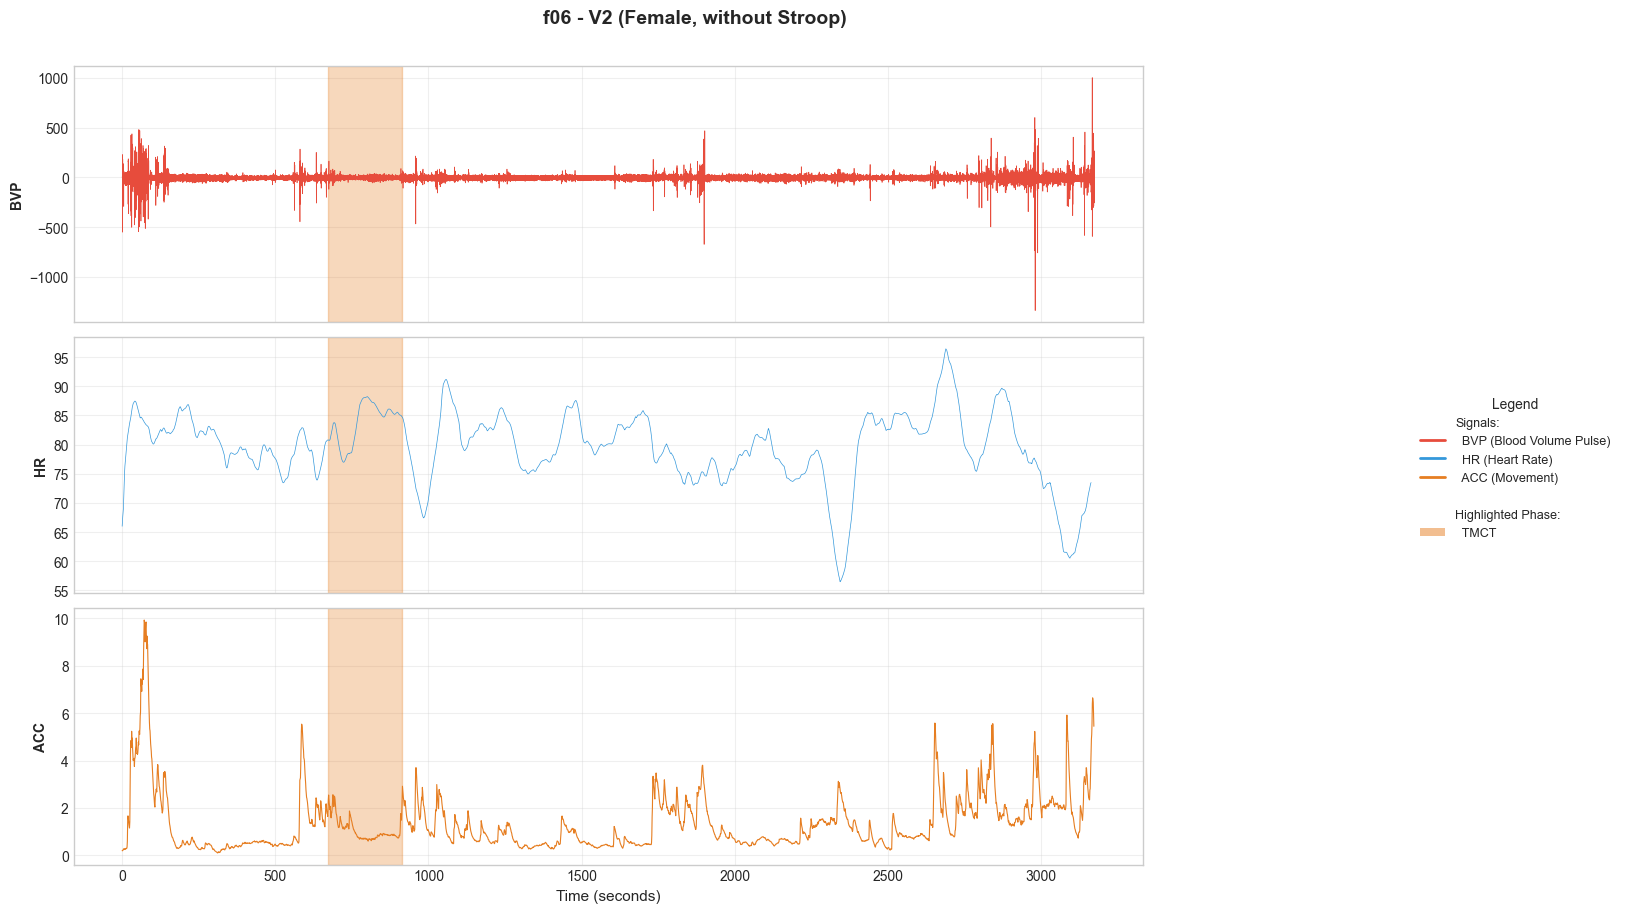

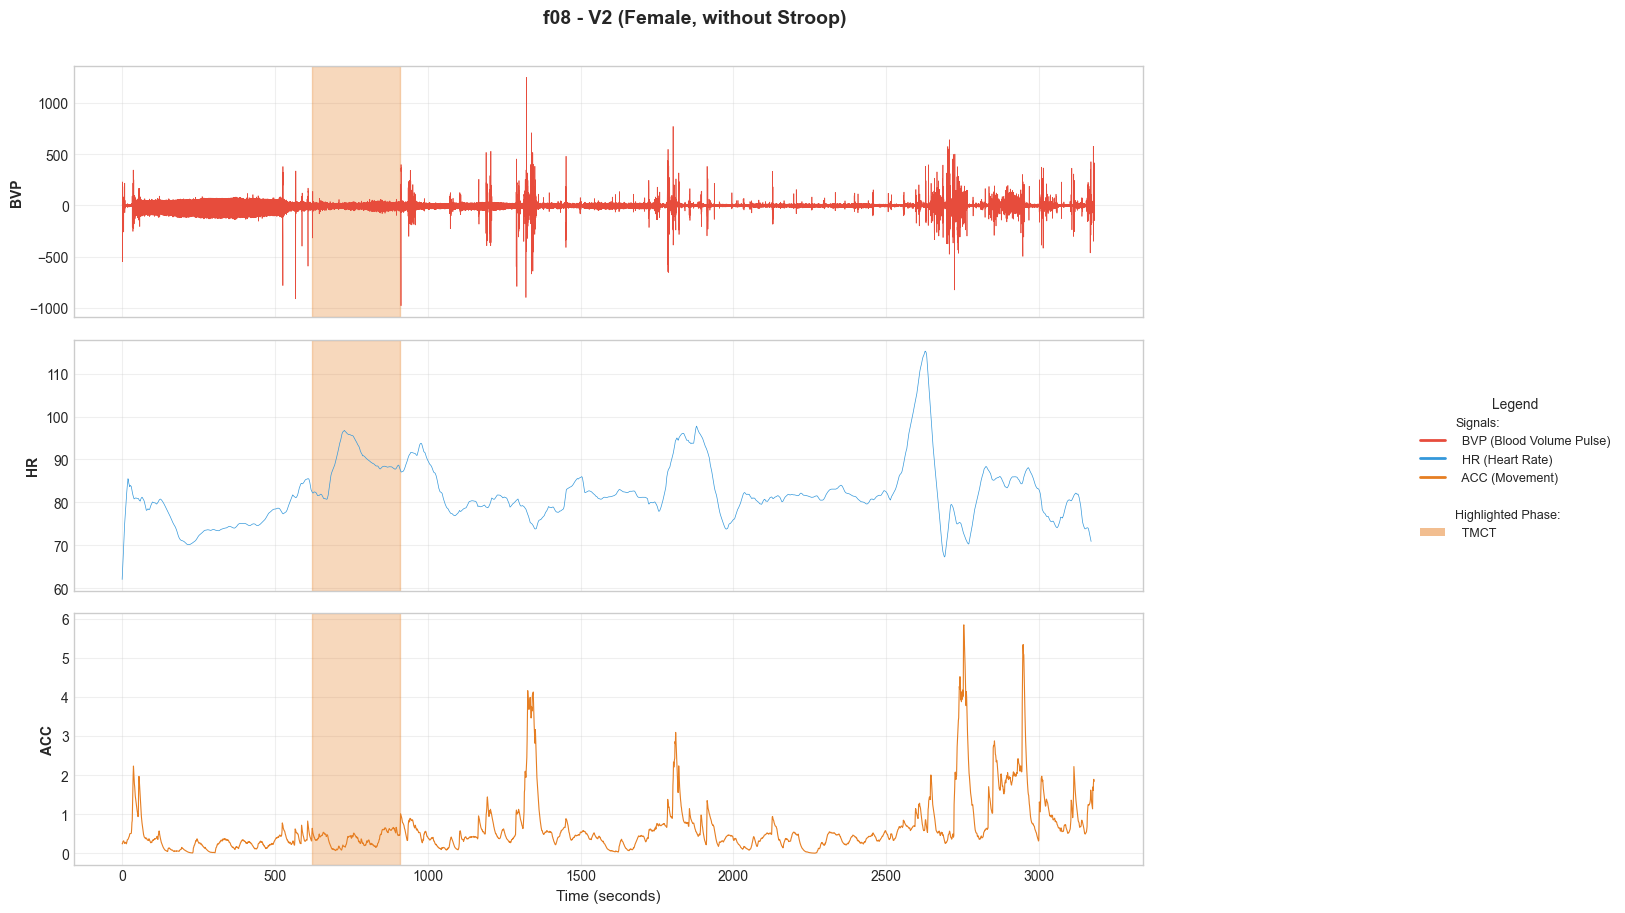

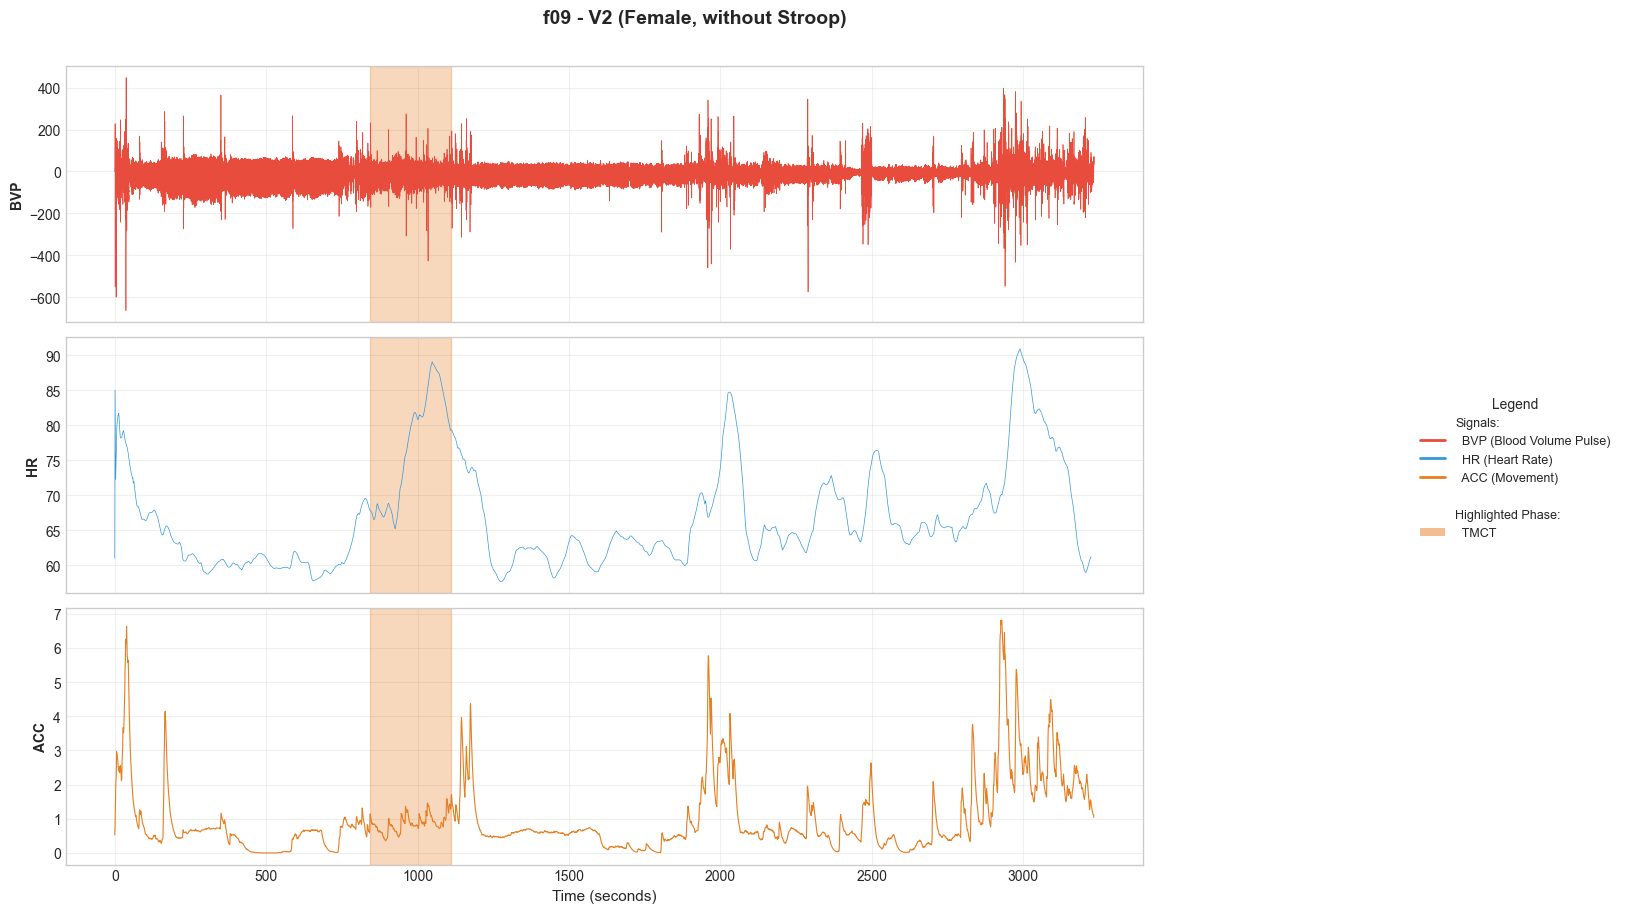

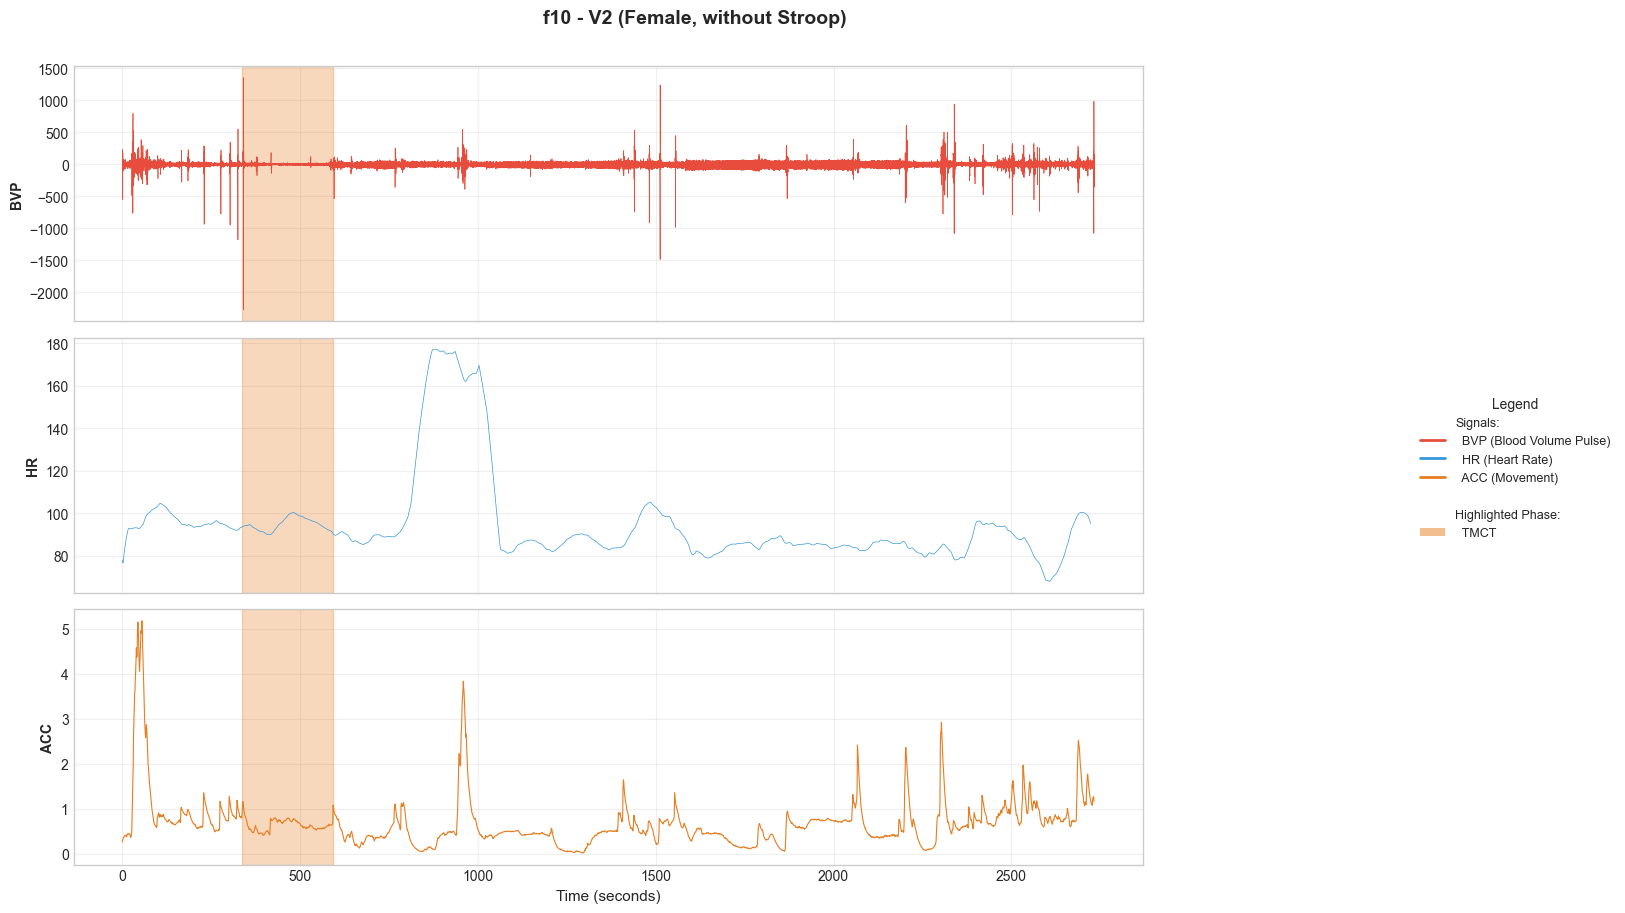

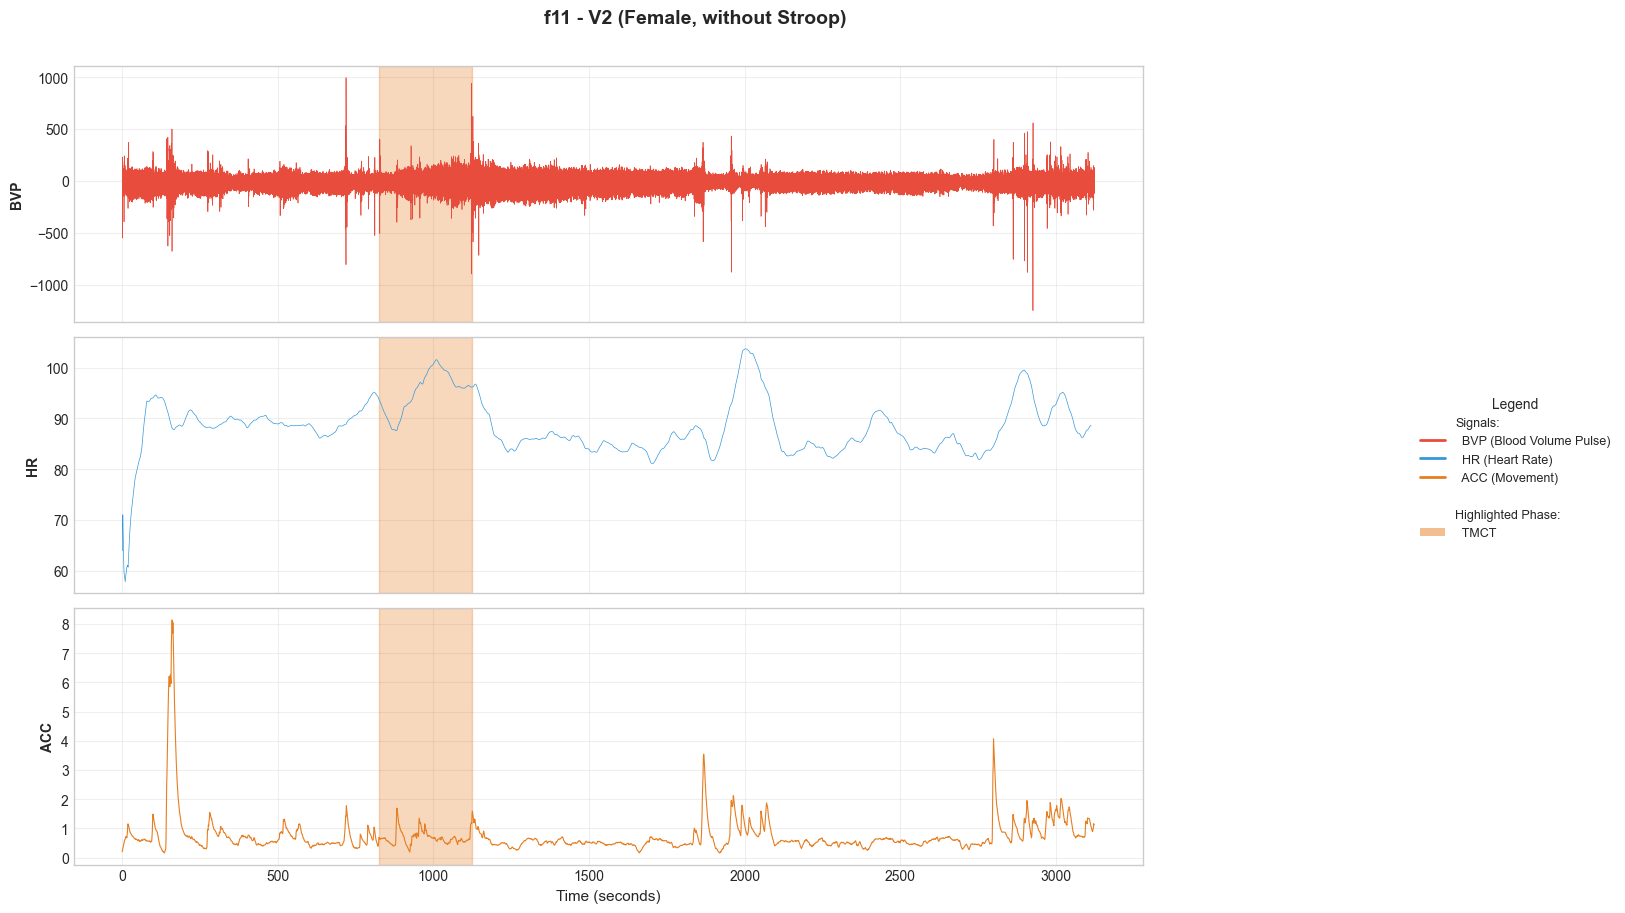

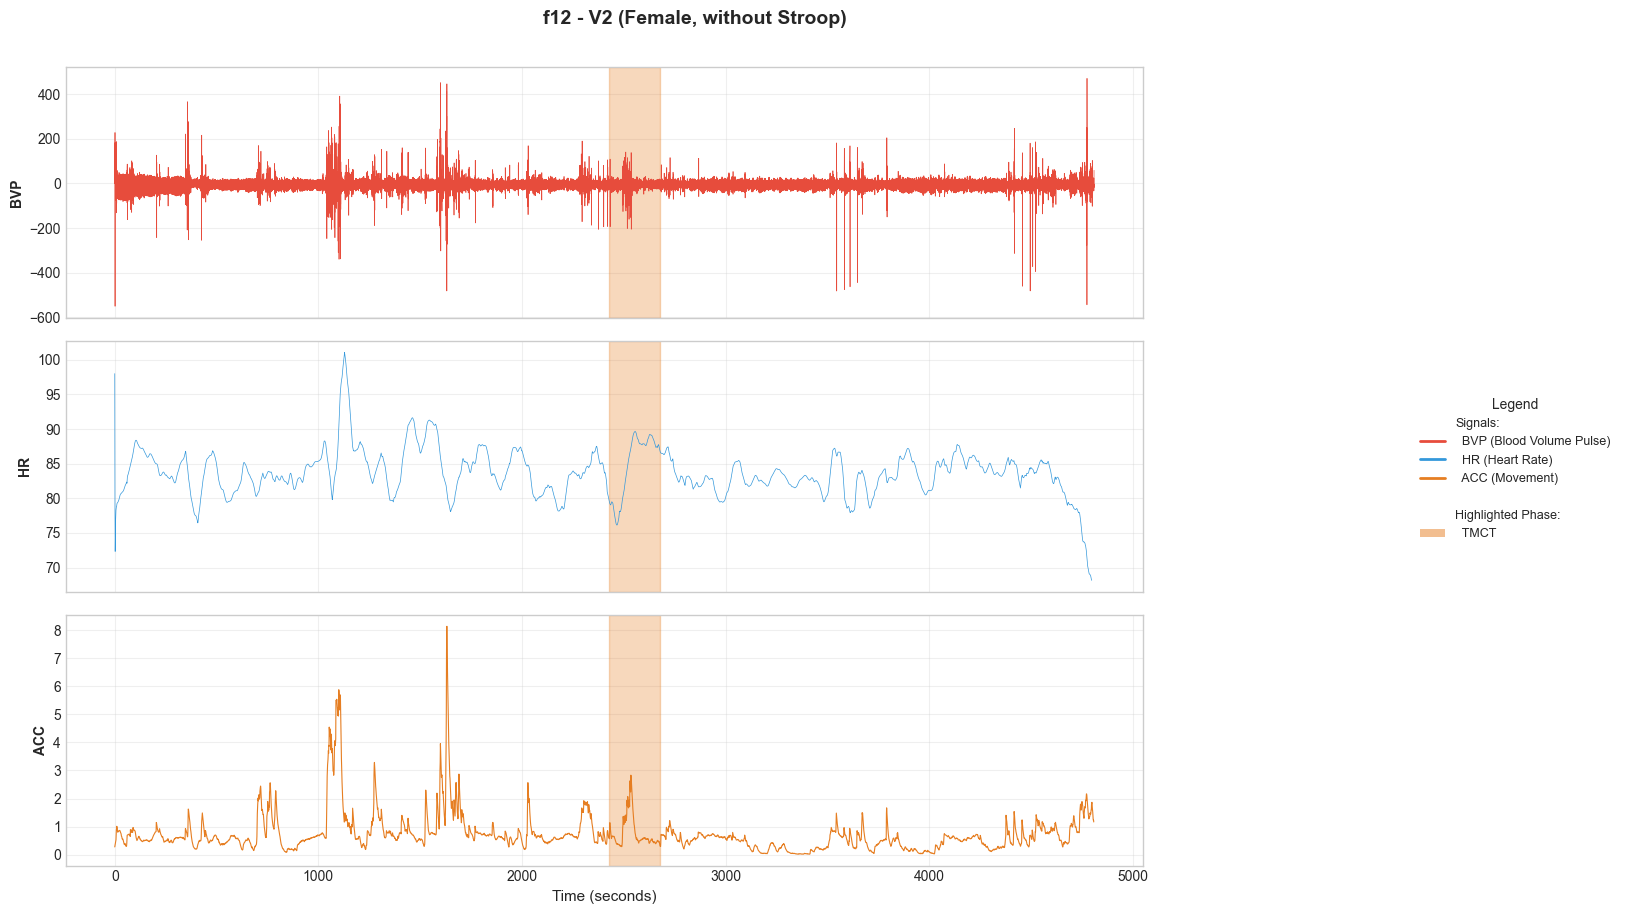

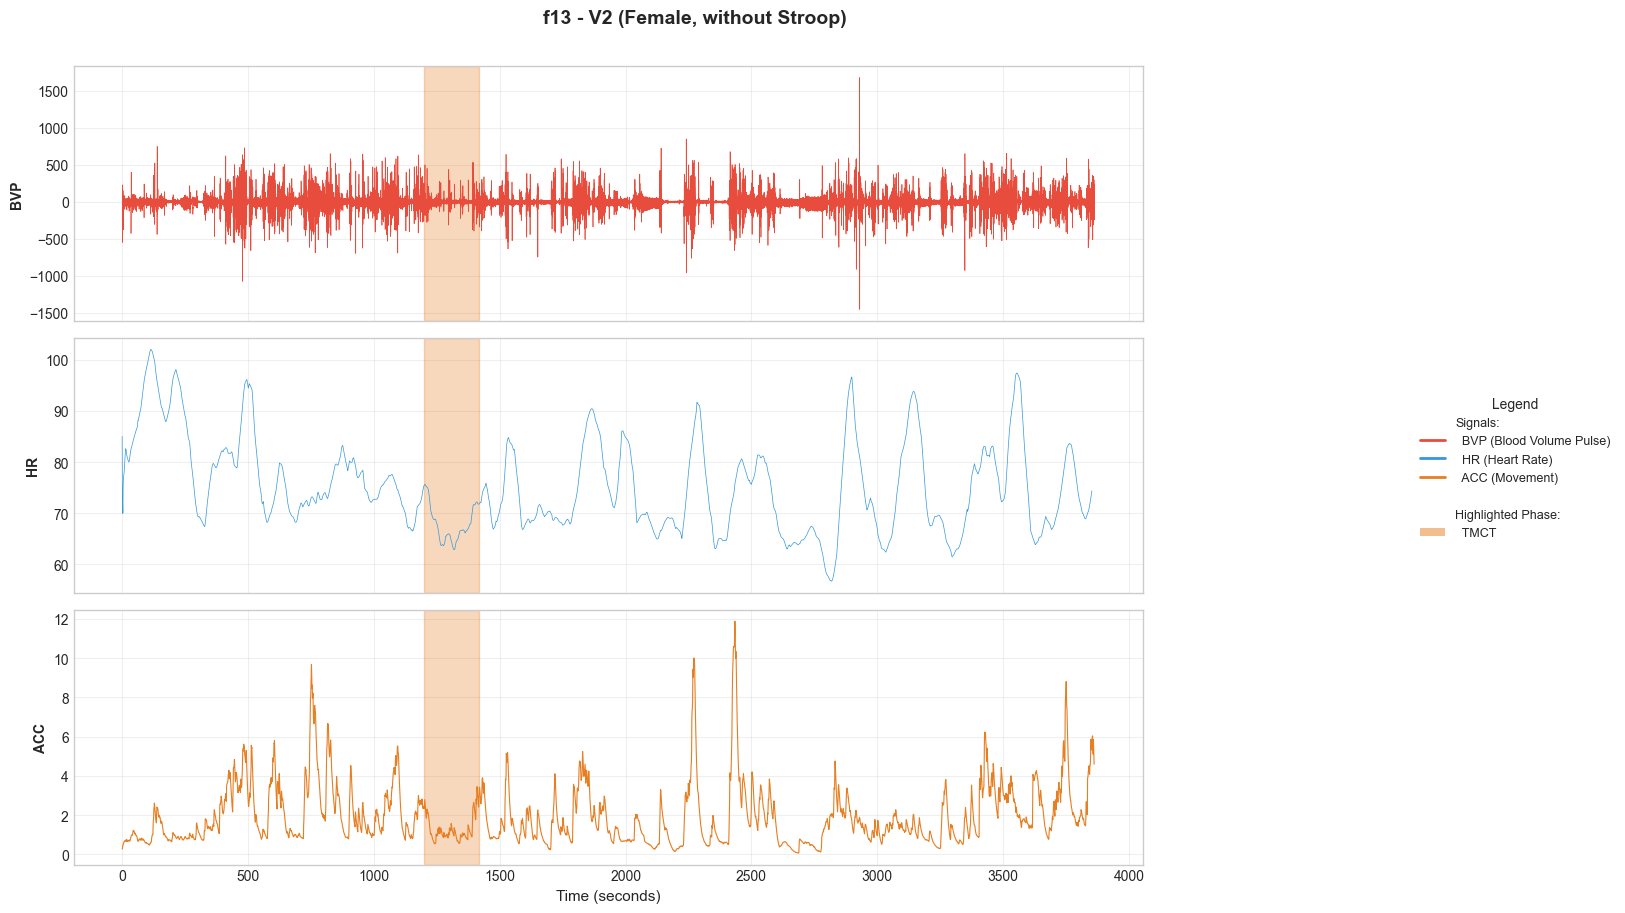

In [15]:
for subject_id in v2_subjects:
    if subject_id in signal_data:
        plot_subject_signals(
            subject_id,
            signal_data[subject_id],
            time_data[subject_id],
            signal_data[subject_id]['tags']
        )
    else:
        print(f"WARNING: {subject_id} not found!")